[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jecampagne/nufftacf/blob/main/notebook/zdcf_vs_nufftacf.ipynb)

# ACF for irregularly-sampled signals: nufftacf vs pyzdcf

This notebook compares the **nufftacf** estimation of the autocorrelation function (ACF) for **irregularly-sampled** time series with the results obtained using the [**pyzdcf**](https://github.com/jecampagne/pyzdcf/) library.

- **nufftacf** relies on the **Non-Uniform Fast Fourier Transform (NUFFT)** and supports **Gaussian** or **Rectangle** kernels, controlled by the `bin_width` parameter.
- **pyzdcf** is based on the **Z-transformed Discrete Correlation Function** ([Alexander 1997](https://ui.adsabs.harvard.edu/abs/1997ASSL..218..163A/abstract)).

### Key Differences
- **Smoothing**: **pyzdcf** does **not** use an explicit smoothing kernel. Instead, it bins pairs of points by lag, requiring a minimum of `minpts` pairs per bin (default: 11). The equivalent "resolution" parameter is therefore `minpts`, not `bin_width`.
- **Error Bars**: **pyzdcf** provides **asymmetric error bars** via Monte Carlo sampling, a feature not natively available in **nufftacf**.

### Tested Series
The notebook uses the same irregularly-sampled synthetic series as in [`notebook/pastas_vs_nufftacf.ipynb`](https://github.com/jecampagne/nufftacf/blob/main/notebook/pastas_vs_nufftacf.ipynb):
- **STS_SIN\*** — Sine waves with varying sampling densities and gaps.
- **STS_EXP\*** — AR(1)-like exponential decay with varying sampling densities.

### Installation Note
> The **pyzdcf** repository was cloned and adapted to ensure compatibility with the pandas and other library versions used in this notebook, allowing it to run on Google Colab. These changes do not affect the quality of the computations.
> Additionally, **pyzdcf** requires CSV files as input (not NumPy arrays directly). A helper function, `run_zdcf`, is provided below to handle temporary file creation transparently.

In [ ]:
!pip -q install   "pyzdcf @ git+https://github.com/jecampagne/pyzdcf.git"
!pip -q install   "nufftacf @ git+https://github.com/jecampagne/nufftacf.git"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tempfile, os, io, contextlib


from pyzdcf import pyzdcf as _pyzdcf
from nufftacf import compute_acf_gaussian_nufft, compute_acf_rectangle_nufft, t_numeric_of

In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size'         : 13,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'legend.fontsize'   : 12,
    'figure.titlesize'  : 16,
    'figure.titleweight': 'bold',
})

In [ ]:
def run_zdcf(t, x, minpts=11, num_MC=200, err_frac=0.01):
    """Run pyzdcf autocorrelation on arrays (t, x).

    Parameters
    ----------
    t        : 1D array, sample times (sorted ascending)
    x        : 1D array, signal values
    minpts   : minimum number of pairs per lag bin (controls resolution)
    num_MC   : number of Monte Carlo runs for error estimation
    err_frac : fractional flux error assigned to each point (pyzdcf requires
               an error column; for synthetic data a small constant is fine)

    Returns
    -------
    result : pandas.DataFrame with columns
             ['tau', '-sig(tau)', '+sig(tau)', 'dcf', '-err(dcf)', '+err(dcf)', '#bin']
    """
    err = np.full(len(t), err_frac * (np.std(x) or 1.0))
    input_dir  = tempfile.mkdtemp() + "/"
    output_dir = tempfile.mkdtemp() + "/"
    lc_name    = "lc.csv"
    np.savetxt(input_dir + lc_name, np.column_stack([t, x, err]), delimiter=",")

    params = {
        "autocf"           : True,
        "prefix"           : "zdcf",
        "uniform_sampling" : False,
        "omit_zero_lags"   : True,
        "minpts"           : minpts,
        "num_MC"           : num_MC,
        "lc1_name"         : lc_name,
    }
    with contextlib.redirect_stdout(io.StringIO()):
        result = _pyzdcf(
            input_dir  = input_dir,
            output_dir = output_dir,
            intr       = False,
            sep        = ",",
            verbose    = False,
            sparse     = "auto",
            parameters = params,
        )
    # cleanup
    os.unlink(input_dir + lc_name)
    return result


## Irregularly-sampled test series

The synthetic test series used in this notebook originate from the [Pastas autocorrelation benchmarks](https://pastas.readthedocs.io/v1.2.0/benchmarks/autocorrelation.html) and are also analyzed in [`notebook/pastas_vs_nufftacf.ipynb`](https://github.com/jecampagne/nufftacf/blob/main/notebook/pastas_vs_nufftacf.ipynb).

They consist of:
- **STS_SIN\*** — Synthetic sine wave series.
- **STS_EXP\*** — AR(1)-like exponential decay series.

Each series is generated at **three sampling densities**: Uniform, Semi-irregular and Irregular sampling.


In [ ]:
dates_csv = [
    "1960-04-28 12:00:00",
    "1960-05-16 12:00:00",
    "1960-05-30 12:00:00",
    "1960-06-15 12:00:00",
    "1960-06-29 12:00:00",
    "1960-07-15 12:00:00",
    "1960-07-29 12:00:00",
    "1960-08-17 12:00:00",
    "1960-08-30 12:00:00",
    "1960-09-15 12:00:00",
    "1960-09-29 12:00:00",
    "1960-10-17 12:00:00",
    "1960-10-31 12:00:00",
    "1960-11-15 12:00:00",
    "1960-11-28 12:00:00",
    "1960-12-14 12:00:00",
    "1960-12-28 12:00:00",
    "1961-01-14 12:00:00",
    "1961-01-30 12:00:00",
    "1961-02-14 12:00:00",
    "1961-02-28 12:00:00",
    "1961-03-14 12:00:00",
    "1961-03-28 12:00:00",
    "1961-04-14 12:00:00",
    "1961-04-28 12:00:00",
    "1961-05-15 12:00:00",
    "1961-05-29 12:00:00",
    "1961-06-14 12:00:00",
    "1961-06-28 12:00:00",
    "1961-07-14 12:00:00",
    "1961-07-28 12:00:00",
    "1961-08-14 12:00:00",
    "1961-08-29 12:00:00",
    "1961-09-14 12:00:00",
    "1961-09-28 12:00:00",
    "1961-10-16 12:00:00",
    "1961-10-30 12:00:00",
    "1961-11-15 12:00:00",
    "1961-11-28 12:00:00",
    "1961-12-14 12:00:00",
    "1961-12-28 12:00:00",
    "1962-01-15 12:00:00",
    "1962-01-29 12:00:00",
    "1962-02-14 12:00:00",
    "1962-02-28 12:00:00",
    "1962-03-14 12:00:00",
    "1962-03-28 12:00:00",
    "1962-04-13 12:00:00",
    "1962-04-27 12:00:00",
    "1962-05-14 12:00:00",
    "1962-05-28 12:00:00",
    "1962-06-14 12:00:00",
    "1962-06-28 12:00:00",
    "1962-07-16 12:00:00",
    "1962-07-27 12:00:00",
    "1962-08-14 12:00:00",
    "1962-08-28 12:00:00",
    "1962-09-14 12:00:00",
    "1962-09-28 12:00:00",
    "1962-10-17 12:00:00",
    "1962-10-29 12:00:00",
    "1962-11-15 12:00:00",
    "1962-11-28 12:00:00",
    "1962-12-14 12:00:00",
    "1963-03-14 12:00:00",
    "1963-03-29 12:00:00",
    "1963-04-17 12:00:00",
    "1963-04-29 12:00:00",
    "1963-05-14 12:00:00",
    "1963-05-28 12:00:00",
    "1963-06-14 12:00:00",
    "1963-06-28 12:00:00",
    "1963-07-15 12:00:00",
    "1963-07-29 12:00:00",
    "1963-08-16 12:00:00",
    "1963-08-28 12:00:00",
    "1963-09-16 12:00:00",
    "1963-09-27 12:00:00",
    "1963-10-14 12:00:00",
    "1963-10-29 12:00:00",
    "1963-11-14 12:00:00",
    "1963-11-29 12:00:00",
    "1963-12-17 12:00:00",
    "1963-12-28 12:00:00",
    "1964-01-14 12:00:00",
    "1964-01-29 12:00:00",
    "1964-02-14 12:00:00",
    "1964-02-28 12:00:00",
    "1964-03-13 12:00:00",
    "1964-03-26 12:00:00",
    "1964-04-14 12:00:00",
    "1964-04-28 12:00:00",
    "1964-05-28 12:00:00",
    "1964-06-29 12:00:00",
    "1964-07-14 12:00:00",
    "1964-07-28 12:00:00",
    "1964-08-28 12:00:00",
    "1964-09-14 12:00:00",
    "1964-09-28 12:00:00",
    "1964-10-14 12:00:00",
    "1964-10-28 12:00:00",
    "1964-11-13 12:00:00",
    "1964-11-27 12:00:00",
    "1964-12-14 12:00:00",
    "1965-01-14 12:00:00",
    "1965-01-28 12:00:00",
    "1965-02-15 12:00:00",
    "1965-02-28 12:00:00",
    "1965-03-01 12:00:00",
    "1965-03-15 12:00:00",
    "1965-04-14 12:00:00",
    "1965-04-29 12:00:00",
    "1965-05-14 12:00:00",
    "1965-05-28 12:00:00",
    "1965-06-14 12:00:00",
    "1965-06-28 12:00:00",
    "1965-07-14 12:00:00",
    "1965-08-13 12:00:00",
    "1965-08-27 12:00:00",
    "1965-09-14 12:00:00",
    "1965-09-29 12:00:00",
    "1965-10-14 12:00:00",
    "1965-10-28 12:00:00",
    "1965-11-15 12:00:00",
    "1965-11-30 12:00:00",
    "1965-12-14 12:00:00",
    "1965-12-28 12:00:00",
    "1966-01-17 12:00:00",
    "1966-01-28 12:00:00",
    "1966-02-14 12:00:00",
    "1966-03-14 12:00:00",
    "1966-03-28 12:00:00",
    "1966-04-14 12:00:00",
    "1966-04-28 12:00:00",
    "1966-05-14 12:00:00",
    "1966-05-28 12:00:00",
    "1966-06-15 12:00:00",
    "1966-06-30 12:00:00",
    "1966-07-14 12:00:00",
    "1966-07-28 12:00:00",
    "1966-08-15 12:00:00",
    "1966-08-29 12:00:00",
    "1966-09-15 12:00:00",
    "1966-09-28 12:00:00",
    "1966-10-14 12:00:00",
    "1966-11-02 12:00:00",
    "1966-11-14 12:00:00",
    "1966-11-28 12:00:00",
    "1966-12-14 12:00:00",
    "1966-12-28 12:00:00",
    "1967-01-16 12:00:00",
    "1967-02-14 12:00:00",
    "1967-02-28 12:00:00",
    "1967-03-14 12:00:00",
    "1967-03-30 12:00:00",
    "1967-04-13 12:00:00",
    "1967-06-28 12:00:00",
    "1967-07-15 12:00:00",
    "1967-07-28 12:00:00",
    "1967-08-14 12:00:00",
    "1967-08-28 12:00:00",
    "1967-09-14 12:00:00",
    "1967-09-28 12:00:00",
    "1967-10-13 12:00:00",
    "1967-12-28 12:00:00",
    "1968-01-15 12:00:00",
    "1968-01-29 12:00:00",
    "1968-02-14 12:00:00",
    "1968-02-28 12:00:00",
    "1968-03-14 12:00:00",
    "1968-03-28 12:00:00",
    "1968-04-16 12:00:00",
    "1968-04-29 12:00:00",
    "1968-05-14 12:00:00",
    "1968-05-28 12:00:00",
    "1968-06-14 12:00:00",
    "1968-06-28 12:00:00",
    "1968-07-29 12:00:00",
    "1968-08-14 12:00:00",
    "1968-08-28 12:00:00",
    "1968-09-13 12:00:00",
    "1968-09-30 12:00:00",
    "1968-10-15 12:00:00",
    "1968-10-29 12:00:00",
    "1968-11-15 12:00:00",
    "1968-11-28 12:00:00",
    "1968-12-16 12:00:00",
    "1969-01-02 12:00:00",
    "1969-01-14 12:00:00",
    "1969-01-28 12:00:00",
    "1969-02-28 12:00:00",
    "1969-03-14 12:00:00",
    "1969-03-28 12:00:00",
    "1969-04-14 12:00:00",
    "1969-04-28 12:00:00",
    "1969-05-14 12:00:00",
    "1969-05-28 12:00:00",
    "1969-06-14 12:00:00",
    "1969-06-27 12:00:00",
    "1969-07-14 12:00:00",
    "1969-08-14 12:00:00",
    "1969-08-28 12:00:00",
    "1969-09-15 12:00:00",
    "1969-09-29 12:00:00",
    "1969-10-14 12:00:00",
    "1969-10-28 12:00:00",
    "1969-11-14 12:00:00",
    "1969-11-28 12:00:00",
    "1969-12-15 12:00:00",
    "1970-01-02 12:00:00",
    "1970-01-14 12:00:00",
    "1970-01-28 12:00:00",
    "1970-02-13 12:00:00",
    "1970-03-13 12:00:00",
    "1970-03-26 12:00:00",
    "1970-04-14 12:00:00",
    "1970-04-28 12:00:00",
    "1970-05-14 12:00:00",
    "1970-05-28 12:00:00",
    "1970-06-16 12:00:00",
    "1970-06-29 12:00:00",
    "1970-07-15 12:00:00",
    "1970-08-14 12:00:00",
    "1970-08-28 12:00:00",
    "1970-09-14 12:00:00",
    "1970-09-28 12:00:00",
    "1970-10-14 12:00:00",
    "1970-10-28 12:00:00",
    "1970-11-14 12:00:00",
    "1970-11-27 12:00:00",
    "1970-12-14 12:00:00",
    "1971-01-04 12:00:00",
    "1971-01-15 12:00:00",
    "1971-01-28 12:00:00",
    "1971-02-15 12:00:00",
    "1971-03-01 12:00:00",
    "1971-03-15 12:00:00",
    "1971-03-29 12:00:00",
    "1971-04-14 12:00:00",
    "1971-04-28 12:00:00",
    "1971-05-14 12:00:00",
    "1971-05-28 12:00:00",
    "1971-06-14 12:00:00",
    "1971-06-28 12:00:00",
    "1971-07-28 12:00:00",
    "1971-08-16 12:00:00",
    "1971-08-29 12:00:00",
    "1971-09-14 12:00:00",
    "1971-09-28 12:00:00",
    "1971-10-14 12:00:00",
    "1971-10-28 12:00:00",
    "1971-11-15 12:00:00",
    "1971-11-29 12:00:00",
    "1971-12-14 12:00:00",
    "1971-12-28 12:00:00",
    "1972-01-14 12:00:00",
    "1972-01-28 12:00:00",
    "1972-02-14 12:00:00",
    "1972-02-28 12:00:00",
    "1972-03-14 12:00:00",
    "1972-03-28 12:00:00",
    "1972-04-14 12:00:00",
    "1972-04-28 12:00:00",
    "1972-05-15 12:00:00",
    "1972-05-29 12:00:00",
    "1972-06-14 12:00:00",
    "1972-06-28 12:00:00",
    "1972-07-28 12:00:00",
    "1972-08-14 12:00:00",
    "1972-08-28 12:00:00",
    "1972-09-14 12:00:00",
    "1972-09-28 12:00:00",
    "1972-10-13 12:00:00",
    "1972-10-27 12:00:00",
    "1972-11-14 12:00:00",
    "1972-11-28 12:00:00",
    "1972-12-14 12:00:00",
    "1973-01-02 12:00:00",
    "1973-01-15 12:00:00",
    "1973-01-29 12:00:00",
    "1973-02-14 12:00:00",
    "1973-02-28 12:00:00",
    "1973-03-14 12:00:00",
    "1973-03-28 12:00:00",
    "1973-04-13 12:00:00",
    "1973-05-01 12:00:00",
    "1973-05-14 12:00:00",
    "1973-05-28 12:00:00",
    "1973-06-14 12:00:00",
    "1973-06-28 12:00:00",
    "1973-07-16 12:00:00",
    "1973-07-30 12:00:00",
    "1973-08-14 12:00:00",
    "1973-08-28 12:00:00",
    "1973-09-14 12:00:00",
    "1973-09-28 12:00:00",
    "1973-10-15 12:00:00",
    "1973-10-29 12:00:00",
    "1973-11-14 12:00:00",
    "1973-11-28 12:00:00",
    "1973-12-14 12:00:00",
    "1974-01-02 12:00:00",
    "1974-01-14 12:00:00",
    "1974-01-28 12:00:00",
    "1974-02-14 12:00:00",
    "1974-02-28 12:00:00",
    "1974-03-14 12:00:00",
    "1974-03-28 12:00:00",
    "1974-04-17 12:00:00",
    "1974-04-29 12:00:00",
    "1974-05-14 12:00:00",
    "1974-05-28 12:00:00",
    "1974-06-14 12:00:00",
    "1974-06-28 12:00:00",
    "1974-07-29 12:00:00",
    "1974-08-14 12:00:00",
    "1974-08-28 12:00:00",
    "1974-09-13 12:00:00",
    "1974-09-27 12:00:00",
    "1974-10-14 12:00:00",
    "1974-10-28 12:00:00",
    "1974-11-14 12:00:00",
    "1974-11-28 12:00:00",
    "1974-12-16 12:00:00",
    "1975-01-01 12:00:00",
    "1975-01-14 12:00:00",
    "1975-01-28 12:00:00",
    "1975-02-14 12:00:00",
    "1975-02-28 12:00:00",
    "1975-03-14 12:00:00",
    "1975-03-27 12:00:00",
    "1975-04-14 12:00:00",
    "1975-04-28 12:00:00",
    "1975-05-14 12:00:00",
    "1975-05-28 12:00:00",
    "1975-06-17 12:00:00",
    "1975-07-10 12:00:00",
    "1975-07-28 12:00:00",
    "1975-08-14 12:00:00",
    "1975-08-28 12:00:00",
    "1975-09-15 12:00:00",
    "1975-09-29 12:00:00",
    "1975-10-14 12:00:00",
    "1975-10-28 12:00:00",
    "1975-11-14 12:00:00",
    "1975-11-28 12:00:00",
    "1975-12-15 12:00:00",
    "1975-12-29 12:00:00",
    "1976-01-14 12:00:00",
    "1976-01-28 12:00:00",
    "1976-02-16 12:00:00",
    "1976-02-26 12:00:00",
    "1976-03-15 12:00:00",
    "1976-03-29 12:00:00",
    "1976-04-14 12:00:00",
    "1976-04-28 12:00:00",
    "1976-05-14 12:00:00",
    "1976-05-26 12:00:00",
    "1976-06-14 12:00:00",
    "1976-06-28 12:00:00",
    "1976-08-13 12:00:00",
    "1976-08-27 12:00:00",
    "1976-09-14 12:00:00",
    "1976-09-27 12:00:00",
    "1976-10-14 12:00:00",
    "1976-10-25 12:00:00",
    "1976-11-15 12:00:00",
    "1976-11-29 12:00:00",
    "1976-12-13 12:00:00",
    "1976-12-27 12:00:00",
    "1977-01-14 12:00:00",
    "1977-01-28 12:00:00",
    "1977-02-14 12:00:00",
    "1977-02-28 12:00:00",
    "1977-03-14 12:00:00",
    "1977-03-28 12:00:00",
    "1977-04-14 12:00:00",
    "1977-04-28 12:00:00",
    "1977-05-12 12:00:00",
    "1977-05-26 12:00:00",
    "1977-06-14 12:00:00",
    "1977-06-28 12:00:00",
    "1977-08-15 12:00:00",
    "1977-08-29 12:00:00",
    "1977-09-14 12:00:00",
    "1977-09-29 12:00:00",
    "1977-10-14 12:00:00",
    "1977-10-28 12:00:00",
    "1977-11-14 12:00:00",
    "1977-11-28 12:00:00",
    "1977-12-15 12:00:00",
    "1977-12-28 12:00:00",
    "1978-01-13 12:00:00",
    "1978-01-30 12:00:00",
    "1978-02-14 12:00:00",
    "1978-02-28 12:00:00",
    "1978-03-14 12:00:00",
    "1978-03-28 12:00:00",
    "1978-04-14 12:00:00",
    "1978-04-28 12:00:00",
    "1978-05-12 12:00:00",
    "1978-05-26 12:00:00",
    "1978-06-13 12:00:00",
    "1978-06-28 12:00:00",
    "1978-07-13 12:00:00",
    "1978-07-31 12:00:00",
    "1978-08-14 12:00:00",
    "1978-08-28 12:00:00",
    "1978-09-14 12:00:00",
    "1978-09-28 12:00:00",
    "1978-10-13 12:00:00",
    "1978-10-27 12:00:00",
    "1978-11-14 12:00:00",
    "1978-11-28 12:00:00",
    "1978-12-14 12:00:00",
    "1979-01-15 12:00:00",
    "1979-02-15 12:00:00",
    "1979-02-28 12:00:00",
    "1979-03-14 12:00:00",
    "1979-03-28 12:00:00",
    "1979-04-12 12:00:00",
    "1979-04-27 12:00:00",
    "1979-05-14 12:00:00",
    "1979-05-28 12:00:00",
    "1979-06-14 12:00:00",
    "1979-06-28 12:00:00",
    "1979-07-13 12:00:00",
    "1979-07-27 12:00:00",
    "1979-08-14 12:00:00",
    "1979-09-14 12:00:00",
    "1979-09-28 12:00:00",
    "1979-10-12 12:00:00",
    "1979-10-29 12:00:00",
    "1979-11-14 12:00:00",
    "1979-11-28 12:00:00",
    "1979-12-14 12:00:00",
    "1979-12-28 12:00:00",
    "1980-01-14 12:00:00",
    "1980-01-28 12:00:00",
    "1980-02-28 12:00:00",
    "1980-03-14 12:00:00",
    "1980-03-28 12:00:00",
    "1980-04-14 12:00:00",
    "1980-04-28 12:00:00",
    "1980-05-14 12:00:00",
    "1980-05-28 12:00:00",
    "1980-06-27 12:00:00",
    "1980-07-14 12:00:00",
    "1980-07-28 12:00:00",
    "1980-08-14 12:00:00",
    "1980-08-28 12:00:00",
    "1980-09-16 12:00:00",
    "1980-09-29 12:00:00",
    "1980-10-14 12:00:00",
    "1980-10-28 12:00:00",
    "1980-11-14 12:00:00",
    "1980-11-28 12:00:00",
    "1980-12-15 12:00:00",
    "1980-12-29 12:00:00",
    "1981-01-14 12:00:00",
    "1981-01-28 12:00:00",
    "1981-02-13 12:00:00",
    "1981-02-27 12:00:00",
    "1981-03-13 12:00:00",
    "1981-03-27 12:00:00",
    "1981-04-14 12:00:00",
    "1981-04-28 12:00:00",
    "1981-05-14 12:00:00",
    "1981-05-27 12:00:00",
    "1981-06-15 12:00:00",
    "1981-06-30 12:00:00",
    "1981-07-14 12:00:00",
    "1981-07-28 12:00:00",
    "1981-08-14 12:00:00",
    "1981-08-28 12:00:00",
    "1981-09-14 12:00:00",
    "1981-09-28 12:00:00",
    "1981-10-14 12:00:00",
    "1981-10-28 12:00:00",
    "1981-11-13 12:00:00",
    "1981-11-27 12:00:00",
    "1981-12-14 12:00:00",
    "1981-12-28 12:00:00",
    "1982-01-15 12:00:00",
    "1982-01-28 12:00:00",
    "1982-02-15 12:00:00",
    "1982-03-01 12:00:00",
    "1982-03-15 12:00:00",
    "1982-03-29 12:00:00",
    "1982-04-14 12:00:00",
    "1982-04-28 12:00:00",
    "1982-05-14 12:00:00",
    "1982-05-28 12:00:00",
    "1982-06-14 12:00:00",
    "1982-06-28 12:00:00",
    "1982-07-14 12:00:00",
    "1982-07-28 12:00:00",
    "1982-08-30 12:00:00",
    "1982-09-14 12:00:00",
    "1982-09-29 12:00:00",
    "1982-10-14 12:00:00",
    "1982-10-28 12:00:00",
    "1982-11-15 12:00:00",
    "1982-11-29 12:00:00",
    "1982-12-14 12:00:00",
    "1982-12-28 12:00:00",
    "1983-01-14 12:00:00",
    "1983-01-28 12:00:00",
    "1983-02-16 12:00:00",
    "1983-02-28 12:00:00",
    "1983-03-14 12:00:00",
    "1983-03-28 12:00:00",
    "1983-04-14 12:00:00",
    "1983-04-28 12:00:00",
    "1983-05-13 12:00:00",
    "1983-05-28 12:00:00",
    "1983-06-14 12:00:00",
    "1983-06-28 12:00:00",
    "1983-07-14 12:00:00",
    "1983-07-28 12:00:00",
    "1983-08-14 12:00:00",
    "1983-08-28 12:00:00",
    "1983-09-14 12:00:00",
    "1983-09-28 12:00:00",
    "1983-10-14 12:00:00",
    "1983-10-28 12:00:00",
    "1983-11-14 12:00:00",
    "1983-11-24 12:00:00",
    "1983-12-14 12:00:00",
    "1983-12-28 12:00:00",
    "1984-01-13 12:00:00",
    "1984-01-27 12:00:00",
    "1984-02-14 12:00:00",
    "1984-02-28 12:00:00",
    "1984-03-14 12:00:00",
    "1984-03-28 12:00:00",
    "1984-04-14 12:00:00",
    "1984-04-27 12:00:00",
    "1984-05-14 12:00:00",
    "1984-05-28 12:00:00",
    "1984-06-14 12:00:00",
    "1984-06-28 12:00:00",
    "1984-07-14 12:00:00",
    "1984-07-27 12:00:00",
    "1984-08-14 12:00:00",
    "1984-08-28 12:00:00",
    "1984-09-14 12:00:00",
    "1984-09-28 12:00:00",
    "1984-10-15 12:00:00",
    "1984-10-28 12:00:00",
    "1984-11-16 12:00:00",
    "1984-11-28 12:00:00",
    "1984-12-14 12:00:00",
    "1984-12-28 12:00:00",
    "1985-01-14 12:00:00",
    "1985-01-28 12:00:00",
    "1985-02-14 12:00:00",
    "1985-02-28 12:00:00",
    "1985-03-14 12:00:00",
    "1985-03-28 12:00:00",
    "1985-04-14 12:00:00",
    "1985-04-28 12:00:00",
    "1985-05-14 12:00:00",
    "1985-05-28 12:00:00",
    "1985-06-14 12:00:00",
    "1985-06-28 12:00:00",
    "1985-07-14 12:00:00",
    "1985-07-28 12:00:00",
    "1985-08-14 12:00:00",
    "1985-08-28 12:00:00",
    "1985-09-14 12:00:00",
    "1985-09-27 12:00:00",
    "1985-10-14 12:00:00",
    "1985-10-28 12:00:00",
    "1985-11-14 12:00:00",
    "1985-11-28 12:00:00",
    "1985-12-14 12:00:00",
    "1985-12-28 12:00:00",
    "1986-01-14 12:00:00",
    "1986-01-28 12:00:00",
    "1986-02-14 12:00:00",
    "1986-02-28 12:00:00",
    "1986-03-14 12:00:00",
    "1986-03-28 12:00:00",
    "1986-04-14 12:00:00",
    "1986-04-28 12:00:00",
    "1986-05-14 12:00:00",
    "1986-05-28 12:00:00",
    "1986-06-14 12:00:00",
    "1986-06-28 12:00:00",
    "1986-07-14 12:00:00",
    "1986-07-28 12:00:00",
    "1986-08-14 12:00:00",
    "1986-08-28 12:00:00",
    "1986-09-15 12:00:00",
    "1986-09-28 12:00:00",
    "1986-10-14 12:00:00",
    "1986-10-28 12:00:00",
    "1986-11-14 12:00:00",
    "1986-11-28 12:00:00",
    "1986-12-14 12:00:00",
    "1986-12-28 12:00:00",
    "1987-01-14 12:00:00",
    "1987-01-28 12:00:00",
    "1987-02-14 12:00:00",
    "1987-02-28 12:00:00",
    "1987-03-14 12:00:00",
    "1987-03-28 12:00:00",
    "1987-04-14 12:00:00",
    "1987-04-27 12:00:00",
    "1987-05-14 12:00:00",
    "1987-05-28 12:00:00",
    "1987-06-14 12:00:00",
    "1987-06-28 12:00:00",
    "1987-07-14 12:00:00",
    "1987-07-28 12:00:00",
    "1987-08-14 12:00:00",
    "1987-08-28 12:00:00",
    "1987-09-14 12:00:00",
    "1987-09-28 12:00:00",
    "1987-10-14 12:00:00",
    "1987-10-28 12:00:00",
    "1987-11-14 12:00:00",
    "1987-11-28 12:00:00",
    "1987-12-14 12:00:00",
    "1987-12-28 12:00:00",
    "1988-01-14 12:00:00",
    "1988-01-28 12:00:00",
    "1988-02-14 12:00:00",
    "1988-02-28 12:00:00",
    "1988-03-14 12:00:00",
    "1988-03-28 12:00:00",
    "1988-04-14 12:00:00",
    "1988-04-28 12:00:00",
    "1988-05-14 12:00:00",
    "1988-05-28 12:00:00",
    "1988-06-14 12:00:00",
    "1988-06-28 12:00:00",
    "1988-07-14 12:00:00",
    "1988-07-28 12:00:00",
    "1988-08-24 12:00:00",
    "1988-09-05 12:00:00",
    "1988-09-14 12:00:00",
    "1988-10-14 12:00:00",
    "1988-10-28 12:00:00",
    "1988-11-14 12:00:00",
    "1988-11-28 12:00:00",
    "1988-12-14 12:00:00",
    "1988-12-28 12:00:00",
    "1989-01-18 12:00:00",
    "1989-01-28 12:00:00",
    "1989-02-14 12:00:00",
    "1989-02-28 12:00:00",
    "1989-03-14 12:00:00",
    "1989-03-28 12:00:00",
    "1989-04-14 12:00:00",
    "1989-04-28 12:00:00",
    "1989-05-14 12:00:00",
    "1989-05-28 12:00:00",
    "1989-06-14 12:00:00",
    "1989-06-28 12:00:00",
    "1989-07-14 12:00:00",
    "1989-07-28 12:00:00",
    "1989-08-28 12:00:00",
    "1989-09-14 12:00:00",
    "1989-09-28 12:00:00",
    "1989-10-14 12:00:00",
    "1989-10-28 12:00:00",
    "1989-11-14 12:00:00",
    "1989-11-28 12:00:00",
    "1989-12-14 12:00:00",
    "1989-12-28 12:00:00",
    "1990-01-14 12:00:00",
    "1990-01-29 12:00:00",
    "1990-02-14 12:00:00",
    "1990-02-27 12:00:00",
    "1990-03-13 12:00:00",
    "1990-03-27 12:00:00",
    "1990-04-14 12:00:00",
    "1990-04-28 12:00:00",
    "1990-05-14 12:00:00",
    "1990-05-28 12:00:00",
    "1990-06-14 12:00:00",
    "1990-06-28 12:00:00",
    "1990-07-14 12:00:00",
    "1990-07-28 12:00:00",
    "1990-08-14 12:00:00",
    "1990-08-28 12:00:00",
    "1990-09-14 12:00:00",
    "1990-09-28 12:00:00",
    "1990-10-14 12:00:00",
    "1990-10-28 12:00:00",
    "1990-11-14 12:00:00",
    "1990-11-28 12:00:00",
    "1990-12-14 12:00:00",
    "1990-12-28 12:00:00",
    "1991-01-14 12:00:00",
    "1991-01-28 12:00:00",
    "1991-02-14 12:00:00",
    "1991-02-28 12:00:00",
    "1991-03-14 12:00:00",
    "1991-03-28 12:00:00",
    "1991-04-28 12:00:00",
    "1991-05-14 12:00:00",
    "1991-05-28 12:00:00",
    "1991-06-14 12:00:00",
    "1991-06-28 12:00:00",
    "1991-07-14 12:00:00",
    "1991-07-28 12:00:00",
    "1991-08-14 12:00:00",
    "1991-08-28 12:00:00",
    "1991-09-14 12:00:00",
    "1991-09-28 12:00:00",
    "1991-10-14 12:00:00",
    "1991-10-28 12:00:00",
    "1991-11-14 12:00:00",
    "1991-11-28 12:00:00",
    "1991-12-14 12:00:00",
    "1991-12-28 12:00:00",
    "1992-01-14 12:00:00",
    "1992-01-28 12:00:00",
    "1992-02-14 12:00:00",
    "1992-03-14 12:00:00",
    "1992-03-28 12:00:00",
    "1992-04-14 12:00:00",
    "1992-04-28 12:00:00",
    "1992-05-14 12:00:00",
    "1992-05-28 12:00:00",
    "1992-06-14 12:00:00",
    "1992-06-28 12:00:00",
    "1992-07-14 12:00:00",
    "1992-07-28 12:00:00",
    "1992-08-14 12:00:00",
    "1992-08-28 12:00:00",
    "1992-09-03 12:00:00",
    "1992-09-14 12:00:00",
    "1992-09-28 12:00:00",
    "1992-10-14 12:00:00",
    "1992-10-28 12:00:00",
    "1992-11-14 12:00:00",
    "1992-11-28 12:00:00",
    "1992-12-14 12:00:00",
    "1992-12-28 12:00:00",
    "1993-01-14 12:00:00",
    "1993-01-28 12:00:00",
    "1993-02-14 12:00:00",
    "1993-02-28 12:00:00",
    "1993-03-14 12:00:00",
    "1993-03-28 12:00:00",
    "1993-04-14 12:00:00",
    "1993-04-28 12:00:00",
    "1993-05-14 12:00:00",
    "1993-05-28 12:00:00",
    "1993-06-14 12:00:00",
    "1993-06-28 12:00:00",
    "1993-07-14 12:00:00",
    "1993-07-28 12:00:00",
    "1993-08-14 12:00:00",
    "1993-08-28 12:00:00",
    "1993-09-14 12:00:00",
    "1993-09-28 12:00:00",
    "1993-10-14 12:00:00",
    "1993-10-28 12:00:00",
    "1993-11-14 12:00:00",
    "1993-11-28 12:00:00",
    "1993-12-14 12:00:00",
    "1993-12-28 12:00:00",
    "1994-01-14 12:00:00",
    "1994-01-28 12:00:00",
    "1994-02-14 12:00:00",
    "1994-02-28 12:00:00",
    "1994-03-14 12:00:00",
    "1994-03-28 12:00:00",
    "1994-04-14 12:00:00",
    "1994-04-28 12:00:00",
    "1994-05-14 12:00:00",
    "1994-05-28 12:00:00",
    "1994-06-14 12:00:00",
    "1994-06-28 12:00:00",
    "1994-07-14 12:00:00",
    "1994-07-28 12:00:00",
    "1994-08-14 12:00:00",
    "1994-08-28 12:00:00",
    "1994-09-14 12:00:00",
    "1994-09-28 12:00:00",
    "1994-10-14 12:00:00",
    "1994-10-28 12:00:00",
    "1994-11-14 12:00:00",
    "1994-11-28 12:00:00",
    "1994-12-14 12:00:00",
    "1994-12-29 12:00:00",
    "1995-01-12 12:00:00",
    "1995-01-14 12:00:00",
    "1995-01-28 12:00:00",
    "1995-02-14 12:00:00",
    "1995-02-28 12:00:00",
    "1995-03-14 12:00:00",
    "1995-03-28 12:00:00",
    "1995-04-14 12:00:00",
    "1995-04-28 12:00:00",
    "1995-05-14 12:00:00",
    "1995-05-28 12:00:00",
    "1995-06-14 12:00:00",
    "1995-07-28 12:00:00",
    "1995-08-14 12:00:00",
    "1995-08-28 12:00:00",
    "1995-09-14 12:00:00",
    "1995-09-28 12:00:00",
    "1995-10-14 12:00:00",
    "1995-10-28 12:00:00",
    "1995-11-14 12:00:00",
    "1995-11-28 12:00:00",
    "1995-12-28 12:00:00",
    "1996-01-14 12:00:00",
    "1996-01-28 12:00:00",
    "1996-02-14 12:00:00",
    "1996-02-28 12:00:00",
    "1996-03-14 12:00:00",
    "1996-03-28 12:00:00",
    "1996-04-14 12:00:00",
    "1996-04-28 12:00:00",
    "1996-05-14 12:00:00",
    "1996-05-28 12:00:00",
    "1996-06-14 12:00:00",
    "1996-06-28 12:00:00",
    "1996-07-14 12:00:00",
    "1996-08-14 12:00:00",
    "1996-08-28 12:00:00",
    "1996-09-14 12:00:00",
    "1996-10-14 12:00:00",
    "1996-10-28 12:00:00",
    "1996-11-14 12:00:00",
    "1996-11-28 12:00:00",
    "1996-12-14 12:00:00",
    "1996-12-28 12:00:00",
    "1997-01-14 12:00:00",
    "1997-01-28 12:00:00",
    "1997-02-14 12:00:00",
    "1997-02-28 12:00:00",
    "1997-03-14 12:00:00",
    "1997-03-28 12:00:00",
    "1997-04-14 12:00:00",
    "1997-04-28 12:00:00",
    "1997-05-14 12:00:00",
    "1997-05-28 12:00:00",
    "1997-06-14 12:00:00",
    "1997-06-28 12:00:00",
    "1997-07-14 12:00:00",
    "1997-07-28 12:00:00",
    "1997-08-14 12:00:00",
    "1997-08-28 12:00:00",
    "1997-09-14 12:00:00",
    "1997-09-28 12:00:00",
    "1997-10-14 12:00:00",
    "1997-11-14 12:00:00",
    "1997-11-28 12:00:00",
    "1997-12-14 12:00:00",
    "1997-12-28 12:00:00",
    "1998-01-14 12:00:00",
    "1998-01-28 12:00:00",
    "1998-02-14 12:00:00",
    "1998-02-28 12:00:00",
    "1998-03-14 12:00:00",
    "1998-04-28 12:00:00",
    "1998-05-14 12:00:00",
    "1998-05-28 12:00:00",
    "1998-06-14 12:00:00",
    "1998-07-14 12:00:00",
    "1998-09-14 12:00:00",
    "1998-09-28 12:00:00",
    "1998-10-14 12:00:00",
    "1998-10-28 12:00:00",
    "1998-11-14 12:00:00",
    "1998-12-14 12:00:00",
    "1998-12-28 12:00:00",
    "1999-01-14 12:00:00",
    "1999-01-28 12:00:00",
    "1999-02-14 12:00:00",
    "1999-02-28 12:00:00",
    "1999-03-28 12:00:00",
    "1999-04-14 12:00:00",
    "1999-04-28 12:00:00",
    "1999-05-14 12:00:00",
    "1999-05-28 12:00:00",
    "1999-06-14 12:00:00",
    "1999-06-28 12:00:00",
    "1999-07-14 12:00:00",
    "1999-07-29 12:00:00",
    "1999-08-14 12:00:00",
    "1999-08-31 12:00:00",
    "1999-09-15 12:00:00",
    "1999-09-30 12:00:00",
    "1999-10-15 12:00:00",
    "1999-10-29 12:00:00",
    "1999-11-28 12:00:00",
    "1999-12-14 12:00:00",
    "1999-12-28 12:00:00",
    "2000-01-14 12:00:00",
    "2000-01-28 12:00:00",
    "2000-02-14 12:00:00",
    "2000-02-28 12:00:00",
    "2000-03-14 12:00:00",
    "2000-03-28 12:00:00",
    "2000-04-14 12:00:00",
    "2000-04-28 12:00:00",
    "2000-05-14 12:00:00",
    "2000-05-28 12:00:00",
    "2000-06-14 12:00:00",
    "2000-06-28 12:00:00",
    "2000-07-14 12:00:00",
    "2000-07-28 12:00:00",
    "2000-08-14 12:00:00",
    "2000-08-28 12:00:00",
    "2000-09-28 12:00:00",
    "2000-10-14 12:00:00",
    "2000-10-28 12:00:00",
    "2000-11-14 12:00:00",
    "2000-12-14 12:00:00",
    "2000-12-28 12:00:00",
    "2001-01-14 12:00:00",
    "2001-01-28 12:00:00",
    "2001-02-14 12:00:00",
    "2001-02-28 12:00:00",
    "2001-03-14 12:00:00",
    "2001-03-28 12:00:00",
    "2001-04-14 12:00:00",
    "2001-04-28 12:00:00",
    "2001-05-14 12:00:00",
    "2001-05-28 12:00:00",
    "2001-06-14 12:00:00",
    "2001-06-28 12:00:00",
    "2001-07-14 12:00:00",
    "2001-07-28 12:00:00",
    "2001-08-14 12:00:00",
    "2001-08-28 12:00:00",
    "2001-09-14 12:00:00",
    "2001-09-28 12:00:00",
    "2001-10-14 12:00:00",
    "2001-11-14 12:00:00",
    "2001-11-28 12:00:00",
    "2001-12-14 12:00:00",
    "2001-12-28 12:00:00",
    "2002-01-14 12:00:00",
    "2002-01-28 12:00:00",
    "2002-02-14 12:00:00",
    "2002-02-28 12:00:00",
    "2002-03-14 12:00:00",
    "2002-03-28 12:00:00",
    "2002-04-14 12:00:00",
    "2002-04-28 12:00:00",
    "2002-05-14 12:00:00",
    "2002-05-28 12:00:00",
    "2002-06-14 12:00:00",
    "2002-06-28 12:00:00",
    "2002-07-14 12:00:00",
    "2002-07-28 12:00:00",
    "2002-08-14 12:00:00",
    "2002-08-28 12:00:00",
    "2002-09-14 12:00:00",
    "2002-09-28 12:00:00",
    "2002-10-14 12:00:00",
    "2002-10-28 12:00:00",
    "2002-11-14 12:00:00",
    "2002-11-28 12:00:00",
    "2002-12-14 12:00:00",
    "2002-12-28 12:00:00",
    "2003-01-14 12:00:00",
    "2003-01-28 12:00:00",
    "2003-02-14 12:00:00",
    "2003-02-28 12:00:00",
    "2003-03-14 12:00:00",
    "2003-03-28 12:00:00",
    "2003-04-14 12:00:00",
    "2003-04-28 12:00:00",
    "2003-05-14 12:00:00",
    "2003-05-26 12:00:00",
    "2003-06-14 12:00:00",
    "2003-06-28 12:00:00",
    "2003-07-14 12:00:00",
    "2003-07-28 12:00:00",
    "2003-08-14 12:00:00",
    "2003-08-28 12:00:00",
    "2003-09-14 12:00:00",
    "2003-09-28 12:00:00",
    "2003-10-14 12:00:00",
    "2003-10-28 12:00:00",
    "2003-11-14 12:00:00",
    "2003-11-28 12:00:00",
    "2003-12-28 12:00:00",
    "2004-01-14 12:00:00",
    "2004-01-28 12:00:00",
    "2004-02-14 12:00:00",
    "2004-02-28 12:00:00",
    "2004-03-28 12:00:00",
    "2004-04-14 12:00:00",
    "2004-04-28 12:00:00",
    "2004-05-14 12:00:00",
    "2004-05-28 12:00:00",
    "2004-06-03 12:00:00",
    "2004-06-10 12:00:00",
    "2004-06-14 12:00:00",
    "2004-06-28 12:00:00",
    "2004-07-14 12:00:00",
    "2004-07-28 12:00:00",
    "2004-08-14 12:00:00",
    "2004-08-28 12:00:00",
    "2004-09-14 12:00:00",
    "2004-09-28 12:00:00",
    "2004-10-14 12:00:00",
    "2004-10-28 12:00:00",
    "2004-11-14 12:00:00",
    "2004-11-28 12:00:00",
    "2004-12-14 12:00:00",
    "2004-12-28 12:00:00",
    "2005-01-14 12:00:00",
    "2005-02-14 12:00:00",
    "2005-02-28 12:00:00",
    "2005-03-14 12:00:00",
    "2005-03-28 12:00:00",
    "2005-04-14 12:00:00",
    "2005-04-28 12:00:00",
    "2005-05-14 12:00:00",
    "2005-05-30 12:00:00",
    "2005-06-13 12:00:00",
    "2005-06-28 12:00:00",
    "2005-08-17 12:00:00",
    "2005-08-28 12:00:00",
    "2005-09-14 12:00:00",
    "2005-10-14 12:00:00",
    "2005-10-28 12:00:00",
    "2005-11-14 12:00:00",
    "2005-11-29 12:00:00",
    "2005-12-15 12:00:00",
    "2005-12-27 12:00:00",
    "2006-01-13 12:00:00",
    "2006-01-30 12:00:00",
    "2006-02-14 12:00:00",
    "2006-02-15 12:00:00",
    "2006-03-28 12:00:00",
    "2006-04-14 12:00:00",
    "2006-04-28 12:00:00",
    "2006-05-17 12:00:00",
    "2006-05-28 12:00:00",
    "2006-06-14 12:00:00",
    "2006-06-28 12:00:00",
    "2006-07-18 12:00:00",
    "2006-07-28 12:00:00",
    "2006-08-14 12:00:00",
    "2006-08-28 12:00:00",
    "2006-09-14 12:00:00",
    "2006-09-28 12:00:00",
    "2006-10-14 12:00:00",
    "2006-10-28 12:00:00",
    "2006-11-14 12:00:00",
    "2006-11-28 12:00:00",
    "2006-12-11 12:00:00",
    "2007-01-05 12:00:00",
    "2007-01-18 12:00:00",
    "2007-01-29 12:00:00",
    "2007-02-14 12:00:00",
    "2007-03-01 12:00:00",
    "2007-03-12 12:00:00",
    "2007-03-26 12:00:00",
    "2007-04-16 12:00:00",
    "2007-06-27 12:00:00",
    "2007-07-12 12:00:00",
    "2007-07-26 12:00:00",
    "2007-08-14 12:00:00",
    "2007-08-30 12:00:00",
    "2007-09-12 12:00:00",
    "2007-09-26 12:00:00",
    "2007-11-14 12:00:00",
    "2007-11-28 12:00:00",
    "2007-12-13 12:00:00",
    "2007-12-27 12:00:00",
    "2008-01-14 12:00:00",
    "2008-01-15 12:00:00",
    "2008-01-28 12:00:00",
    "2008-02-14 12:00:00",
    "2008-02-29 12:00:00",
    "2008-03-14 12:00:00",
    "2008-04-01 12:00:00",
    "2008-04-14 12:00:00",
    "2008-04-28 12:00:00",
    "2008-05-15 12:00:00",
    "2008-05-27 12:00:00",
    "2008-06-16 12:00:00",
    "2008-07-14 12:00:00",
    "2008-07-28 12:00:00",
    "2008-08-28 12:00:00",
    "2008-09-15 12:00:00",
    "2008-10-13 12:00:00",
    "2008-10-27 12:00:00",
    "2008-11-14 12:00:00",
    "2008-11-27 12:00:00",
    "2008-12-15 12:00:00",
    "2008-12-30 12:00:00",
    "2009-01-14 12:00:00",
    "2009-01-28 12:00:00",
    "2009-02-13 12:00:00",
    "2009-03-02 12:00:00",
    "2009-03-17 12:00:00",
    "2009-03-30 12:00:00",
    "2009-04-14 12:00:00",
    "2009-04-28 12:00:00",
    "2009-05-14 12:00:00",
    "2009-05-28 12:00:00",
    "2009-06-16 12:00:00",
    "2009-06-30 12:00:00",
    "2009-07-13 12:00:00",
    "2009-07-28 12:00:00",
    "2009-08-28 12:00:00",
    "2009-09-14 12:00:00",
    "2009-09-29 12:00:00",
    "2009-10-13 12:00:00",
    "2009-11-16 12:00:00",
    "2009-12-01 12:00:00",
    "2009-12-14 12:00:00",
    "2009-12-28 12:00:00",
    "2010-01-13 12:00:00",
    "2010-01-19 17:00:00",
    "2010-01-20 12:00:00",
    "2010-01-21 12:00:00",
    "2010-01-22 12:00:00",
    "2010-01-23 12:00:00",
    "2010-01-24 12:00:00",
    "2010-01-25 12:00:00",
    "2010-01-26 12:00:00",
    "2010-01-27 12:00:00",
    "2010-01-28 12:00:00",
    "2010-01-29 12:00:00",
    "2010-01-30 12:00:00",
    "2010-01-31 12:00:00",
    "2010-02-01 12:00:00",
    "2010-02-02 12:00:00",
    "2010-02-03 12:00:00",
    "2010-02-04 12:00:00",
    "2010-02-05 12:00:00",
    "2010-02-06 12:00:00",
    "2010-02-07 12:00:00",
    "2010-02-08 12:00:00",
    "2010-02-09 12:00:00",
    "2010-02-10 12:00:00",
    "2010-02-11 12:00:00",
    "2010-02-12 12:00:00",
    "2010-02-13 12:00:00",
    "2010-02-14 12:00:00",
    "2010-02-15 12:00:00",
    "2010-02-16 12:00:00",
    "2010-02-17 12:00:00",
    "2010-02-18 12:00:00",
    "2010-02-19 12:00:00",
    "2010-02-20 12:00:00",
    "2010-02-21 12:00:00",
    "2010-02-22 12:00:00",
    "2010-02-23 12:00:00",
    "2010-02-24 12:00:00",
    "2010-02-25 12:00:00",
    "2010-02-26 12:00:00",
    "2010-02-27 12:00:00",
    "2010-02-28 12:00:00",
    "2010-03-01 12:00:00",
    "2010-03-02 12:00:00",
    "2010-03-03 12:00:00",
    "2010-03-04 12:00:00",
    "2010-03-05 12:00:00",
    "2010-03-06 12:00:00",
    "2010-03-07 12:00:00",
    "2010-03-08 12:00:00",
    "2010-03-09 12:00:00",
    "2010-03-10 12:00:00",
    "2010-03-11 12:00:00",
    "2010-03-12 12:00:00",
    "2010-03-13 12:00:00",
    "2010-03-14 12:00:00",
    "2010-03-15 12:00:00",
    "2010-03-16 12:00:00",
    "2010-03-17 12:00:00",
    "2010-03-18 12:00:00",
    "2010-03-19 12:00:00",
    "2010-03-20 12:00:00",
    "2010-03-21 12:00:00",
    "2010-03-22 12:00:00",
    "2010-03-23 12:00:00",
    "2010-03-24 12:00:00",
    "2010-03-25 12:00:00",
    "2010-03-26 12:00:00",
    "2010-03-27 12:00:00",
    "2010-03-28 12:00:00",
    "2010-03-29 12:00:00",
    "2010-03-30 12:00:00",
    "2010-03-31 12:00:00",
    "2010-04-01 12:00:00",
    "2010-04-02 12:00:00",
    "2010-04-03 12:00:00",
    "2010-04-04 12:00:00",
    "2010-04-05 12:00:00",
    "2010-04-06 12:00:00",
    "2010-04-07 12:00:00",
    "2010-04-08 12:00:00",
    "2010-04-09 12:00:00",
    "2010-04-10 12:00:00",
    "2010-04-11 12:00:00",
    "2010-04-12 12:00:00",
    "2010-04-13 12:00:00",
    "2010-04-14 12:00:00",
    "2010-04-15 12:00:00",
    "2010-04-16 12:00:00",
    "2010-04-17 12:00:00",
    "2010-04-18 12:00:00",
    "2010-04-19 12:00:00",
    "2010-04-20 12:00:00",
    "2010-04-21 12:00:00",
    "2010-04-22 12:00:00",
    "2010-04-23 12:00:00",
    "2010-04-24 12:00:00",
    "2010-04-25 12:00:00",
    "2010-04-26 12:00:00",
    "2010-04-27 12:00:00",
    "2010-04-28 12:00:00",
    "2010-04-29 12:00:00",
    "2010-04-30 12:00:00",
    "2010-05-01 12:00:00",
    "2010-05-02 12:00:00",
    "2010-05-03 12:00:00",
    "2010-05-04 12:00:00",
    "2010-05-05 12:00:00",
    "2010-05-06 12:00:00",
    "2010-05-07 12:00:00",
    "2010-05-08 12:00:00",
    "2010-05-09 12:00:00",
    "2010-05-10 12:00:00",
    "2010-05-11 12:00:00",
    "2010-05-12 12:00:00",
    "2010-05-13 12:00:00",
    "2010-05-14 12:00:00",
    "2010-05-15 12:00:00",
    "2010-05-16 12:00:00",
    "2010-05-17 12:00:00",
    "2010-05-18 12:00:00",
    "2010-05-19 12:00:00",
    "2010-05-20 12:00:00",
    "2010-05-21 12:00:00",
    "2010-05-22 12:00:00",
    "2010-05-23 12:00:00",
    "2010-05-24 12:00:00",
    "2010-05-25 12:00:00",
    "2010-05-26 12:00:00",
    "2010-05-27 12:00:00",
    "2010-05-28 12:00:00",
    "2010-05-29 12:00:00",
    "2010-05-30 12:00:00",
    "2010-05-31 12:00:00",
    "2010-06-01 12:00:00",
    "2010-06-02 12:00:00",
    "2010-06-03 12:00:00",
    "2010-06-04 12:00:00",
    "2010-06-05 12:00:00",
    "2010-06-06 12:00:00",
    "2010-06-07 12:00:00",
    "2010-06-08 12:00:00",
    "2010-06-09 12:00:00",
    "2010-06-10 12:00:00",
    "2010-06-11 12:00:00",
    "2010-06-12 12:00:00",
    "2010-06-13 12:00:00",
    "2010-06-14 12:00:00",
    "2010-06-15 12:00:00",
    "2010-06-16 12:00:00",
    "2010-06-17 12:00:00",
    "2010-06-18 12:00:00",
    "2010-06-19 12:00:00",
    "2010-06-20 12:00:00",
    "2010-06-21 12:00:00",
    "2010-06-22 12:00:00",
    "2010-06-23 12:00:00",
    "2010-06-24 12:00:00",
    "2010-06-25 12:00:00",
    "2010-06-26 12:00:00",
    "2010-06-27 12:00:00",
    "2010-06-28 12:00:00",
    "2010-06-29 12:00:00",
    "2010-06-30 12:00:00",
    "2010-07-01 12:00:00",
    "2010-07-02 12:00:00",
    "2010-07-03 12:00:00",
    "2010-07-04 12:00:00",
    "2010-07-05 12:00:00",
    "2010-07-06 12:00:00",
    "2010-07-07 12:00:00",
    "2010-07-08 12:00:00",
    "2010-07-09 12:00:00",
    "2010-07-10 12:00:00",
    "2010-07-11 12:00:00",
    "2010-07-12 12:00:00",
    "2010-07-13 12:00:00",
    "2010-07-14 12:00:00",
    "2010-07-15 12:00:00",
    "2010-07-16 12:00:00",
    "2010-07-17 12:00:00",
    "2010-07-18 12:00:00",
    "2010-07-19 12:00:00",
    "2010-07-20 12:00:00",
    "2010-07-21 12:00:00",
    "2010-07-22 12:00:00",
    "2010-07-23 12:00:00",
    "2010-07-24 12:00:00",
    "2010-07-25 12:00:00",
    "2010-07-26 12:00:00",
    "2010-07-27 12:00:00",
    "2010-07-28 12:00:00",
    "2010-07-29 12:00:00",
    "2010-07-30 12:00:00",
    "2010-07-31 12:00:00",
    "2010-08-01 12:00:00",
    "2010-08-02 12:00:00",
    "2010-08-03 12:00:00",
    "2010-08-04 12:00:00",
    "2010-08-05 12:00:00",
    "2010-08-06 12:00:00",
    "2010-08-07 12:00:00",
    "2010-08-08 12:00:00",
    "2010-08-09 12:00:00",
    "2010-08-10 12:00:00",
    "2010-08-11 12:00:00",
    "2010-08-12 12:00:00",
    "2010-08-13 12:00:00",
    "2010-08-14 12:00:00",
    "2010-08-15 12:00:00",
    "2010-08-16 12:00:00",
    "2010-08-17 12:00:00",
    "2010-08-18 12:00:00",
    "2010-08-19 12:00:00",
    "2010-08-20 12:00:00",
    "2010-08-21 12:00:00",
    "2010-08-22 12:00:00",
    "2010-08-23 12:00:00",
    "2010-08-24 12:00:00",
    "2010-08-25 12:00:00",
    "2010-08-26 12:00:00",
    "2010-08-27 12:00:00",
    "2010-08-28 12:00:00",
    "2010-08-29 12:00:00",
    "2010-08-30 12:00:00",
    "2010-08-31 12:00:00",
    "2010-09-01 12:00:00",
    "2010-09-02 12:00:00",
    "2010-09-03 12:00:00",
    "2010-09-04 12:00:00",
    "2010-09-05 12:00:00",
    "2010-09-06 12:00:00",
    "2010-09-07 12:00:00",
    "2010-09-08 12:00:00",
    "2010-09-09 12:00:00",
    "2010-09-10 12:00:00",
    "2010-09-11 12:00:00",
    "2010-09-12 12:00:00",
    "2010-09-13 12:00:00",
    "2010-09-14 12:00:00",
    "2010-09-15 12:00:00",
    "2010-09-16 12:00:00",
    "2010-09-17 12:00:00",
    "2010-09-18 12:00:00",
    "2010-09-19 12:00:00",
    "2010-09-20 12:00:00",
    "2010-09-21 12:00:00",
    "2010-09-22 12:00:00",
    "2010-09-23 12:00:00",
    "2010-09-24 12:00:00",
    "2010-09-25 12:00:00",
    "2010-09-26 12:00:00",
    "2010-09-27 12:00:00",
    "2010-09-28 12:00:00",
    "2010-09-29 12:00:00",
    "2010-09-30 12:00:00",
    "2010-10-01 12:00:00",
    "2010-10-02 12:00:00",
    "2010-10-03 12:00:00",
    "2010-10-04 12:00:00",
    "2010-10-05 12:00:00",
    "2010-10-06 12:00:00",
    "2010-10-07 12:00:00",
    "2010-10-08 12:00:00",
    "2010-10-09 12:00:00",
    "2010-10-10 12:00:00",
    "2010-10-11 12:00:00",
    "2010-10-12 12:00:00",
    "2010-10-13 12:00:00",
    "2010-10-14 12:00:00",
    "2010-10-15 12:00:00",
    "2010-10-16 12:00:00",
    "2010-10-17 12:00:00",
    "2010-10-18 12:00:00",
    "2010-10-19 12:00:00",
    "2010-10-20 12:00:00",
    "2010-10-21 12:00:00",
    "2010-10-22 12:00:00",
    "2010-10-23 12:00:00",
    "2010-10-24 12:00:00",
    "2010-10-25 12:00:00",
    "2010-10-26 12:00:00",
    "2010-10-27 12:00:00",
    "2010-10-28 12:00:00",
    "2010-10-29 12:00:00",
    "2010-10-30 12:00:00",
    "2010-10-31 12:00:00",
    "2010-11-01 12:00:00",
    "2010-11-02 12:00:00",
    "2010-11-03 12:00:00",
    "2010-11-04 12:00:00",
    "2010-11-05 12:00:00",
    "2010-11-06 12:00:00",
    "2010-11-07 12:00:00",
    "2010-11-08 12:00:00",
    "2010-11-09 12:00:00",
    "2010-11-10 12:00:00",
    "2010-11-11 12:00:00",
    "2010-11-12 12:00:00",
    "2010-11-13 12:00:00",
    "2010-11-14 12:00:00",
    "2010-11-15 12:00:00",
    "2010-11-16 12:00:00",
    "2010-11-17 12:00:00",
    "2010-11-18 12:00:00",
    "2010-11-19 12:00:00",
    "2010-11-20 12:00:00",
    "2010-11-21 12:00:00",
    "2010-11-22 12:00:00",
    "2010-11-23 12:00:00",
    "2010-11-24 12:00:00",
    "2010-11-25 12:00:00",
    "2010-11-26 12:00:00",
    "2010-11-27 12:00:00",
    "2010-11-28 12:00:00",
    "2010-11-29 12:00:00",
    "2010-11-30 12:00:00",
    "2010-12-01 12:00:00",
    "2010-12-02 12:00:00",
    "2010-12-03 12:00:00",
    "2010-12-04 12:00:00",
    "2010-12-05 12:00:00",
    "2010-12-06 12:00:00",
    "2010-12-07 12:00:00",
    "2010-12-08 12:00:00",
    "2010-12-09 12:00:00",
    "2010-12-10 12:00:00",
    "2010-12-11 12:00:00",
    "2010-12-12 12:00:00",
    "2010-12-13 12:00:00",
    "2010-12-14 12:00:00",
    "2010-12-15 12:00:00",
    "2010-12-16 12:00:00",
    "2010-12-17 12:00:00",
    "2010-12-18 12:00:00",
    "2010-12-19 12:00:00",
    "2010-12-20 12:00:00",
    "2010-12-21 12:00:00",
    "2010-12-22 12:00:00",
    "2010-12-23 12:00:00",
    "2010-12-24 12:00:00",
    "2010-12-25 12:00:00",
    "2010-12-26 12:00:00",
    "2010-12-27 12:00:00",
    "2010-12-28 12:00:00",
    "2010-12-29 12:00:00",
    "2010-12-30 12:00:00",
    "2010-12-31 12:00:00",
    "2011-01-01 12:00:00",
    "2011-01-02 12:00:00",
    "2011-01-03 12:00:00",
    "2011-01-04 12:00:00",
    "2011-01-05 12:00:00",
    "2011-01-06 12:00:00",
    "2011-01-07 12:00:00",
    "2011-01-08 12:00:00",
    "2011-01-09 12:00:00",
    "2011-01-10 12:00:00",
    "2011-01-11 12:00:00",
    "2011-01-12 12:00:00",
    "2011-01-13 12:00:00",
    "2011-01-14 12:00:00",
    "2011-01-15 12:00:00",
    "2011-01-16 12:00:00",
    "2011-01-17 12:00:00",
    "2011-01-18 12:00:00",
    "2011-01-19 12:00:00",
    "2011-01-20 12:00:00",
    "2011-01-21 12:00:00",
    "2011-01-22 12:00:00",
    "2011-01-23 12:00:00",
    "2011-01-24 12:00:00",
    "2011-01-25 11:50:00",
    "2011-01-26 11:50:00",
    "2011-01-27 11:50:00",
    "2011-01-28 11:50:00",
    "2011-01-29 11:50:00",
    "2011-01-30 11:50:00",
    "2011-01-31 11:50:00",
    "2011-02-01 11:50:00",
    "2011-02-02 11:50:00",
    "2011-02-03 11:50:00",
    "2011-02-04 11:50:00",
    "2011-02-05 11:50:00",
    "2011-02-06 11:50:00",
    "2011-02-07 11:50:00",
    "2011-02-08 11:50:00",
    "2011-02-09 11:50:00",
    "2011-02-10 11:50:00",
    "2011-02-11 11:50:00",
    "2011-02-12 11:50:00",
    "2011-02-13 11:50:00",
    "2011-02-14 11:50:00",
    "2011-02-15 11:50:00",
    "2011-02-16 11:50:00",
    "2011-02-17 11:50:00",
    "2011-02-18 11:50:00",
    "2011-02-19 11:50:00",
    "2011-02-20 11:50:00",
    "2011-02-21 11:50:00",
    "2011-02-22 11:50:00",
    "2011-02-23 11:50:00",
    "2011-02-24 11:50:00",
    "2011-02-25 11:50:00",
    "2011-02-26 11:50:00",
    "2011-02-27 11:50:00",
    "2011-02-28 11:50:00",
    "2011-03-01 11:50:00",
    "2011-03-02 11:50:00",
    "2011-03-03 11:50:00",
    "2011-03-04 11:50:00",
    "2011-03-05 11:50:00",
    "2011-03-06 11:50:00",
    "2011-03-07 11:50:00",
    "2011-03-08 11:50:00",
    "2011-03-09 11:50:00",
    "2011-03-10 11:50:00",
    "2011-03-11 11:50:00",
    "2011-03-12 11:50:00",
    "2011-03-13 11:50:00",
    "2011-03-14 11:50:00",
    "2011-03-15 11:50:00",
    "2011-03-16 11:50:00",
    "2011-03-17 11:50:00",
    "2011-03-18 11:50:00",
    "2011-03-19 11:50:00",
    "2011-03-20 11:50:00",
    "2011-03-21 11:50:00",
    "2011-03-22 11:50:00",
    "2011-03-23 11:50:00",
    "2011-03-24 11:50:00",
    "2011-03-25 11:50:00",
    "2011-03-26 11:50:00",
    "2011-03-27 11:50:00",
    "2011-03-28 11:50:00",
    "2011-03-29 11:50:00",
    "2011-03-30 11:50:00",
    "2011-03-31 11:50:00",
    "2011-04-01 11:50:00",
    "2011-04-02 11:50:00",
    "2011-04-03 11:50:00",
    "2011-04-04 11:50:00",
    "2011-04-05 11:50:00",
    "2011-04-06 11:50:00",
    "2011-04-07 11:50:00",
    "2011-04-08 11:50:00",
    "2011-04-09 11:50:00",
    "2011-04-10 11:50:00",
    "2011-04-11 11:50:00",
    "2011-04-12 11:50:00",
    "2011-04-13 11:50:00",
    "2011-04-14 11:50:00",
    "2011-04-15 11:50:00",
    "2011-04-16 11:50:00",
    "2011-04-17 11:50:00",
    "2011-04-18 11:50:00",
    "2011-04-19 11:50:00",
    "2011-04-20 11:50:00",
    "2011-04-21 11:50:00",
    "2011-04-22 11:50:00",
    "2011-04-23 11:50:00",
    "2011-04-24 11:50:00",
    "2011-04-25 11:50:00",
    "2011-04-26 11:50:00",
    "2011-04-27 11:50:00",
    "2011-04-28 11:50:00",
    "2011-04-29 11:50:00",
    "2011-04-30 11:50:00",
    "2011-05-01 11:50:00",
    "2011-05-02 11:50:00",
    "2011-05-03 11:50:00",
    "2011-05-04 11:50:00",
    "2011-05-05 11:50:00",
    "2011-05-06 11:50:00",
    "2011-05-07 11:50:00",
    "2011-05-08 11:50:00",
    "2011-05-09 11:50:00",
    "2011-05-10 11:50:00",
    "2011-05-11 11:50:00",
    "2011-05-12 11:50:00",
    "2011-05-13 11:50:00",
    "2011-05-14 11:50:00",
    "2011-05-15 11:50:00",
    "2011-05-16 11:50:00",
    "2011-05-17 11:50:00",
    "2011-05-18 11:50:00",
    "2011-05-19 11:50:00",
    "2011-05-20 11:50:00",
    "2011-05-21 11:50:00",
    "2011-05-22 11:50:00",
    "2011-05-23 11:50:00",
    "2011-05-24 11:50:00",
    "2011-05-25 11:50:00",
    "2011-05-26 11:50:00",
    "2011-05-27 11:50:00",
    "2011-05-28 11:50:00",
    "2011-05-29 11:50:00",
    "2011-05-30 11:50:00",
    "2011-05-31 11:50:00",
    "2011-06-01 11:50:00",
    "2011-06-02 11:50:00",
    "2011-06-03 11:50:00",
    "2011-06-04 11:50:00",
    "2011-06-05 11:50:00",
    "2011-06-06 11:50:00",
    "2011-06-07 11:50:00",
    "2011-06-08 11:50:00",
    "2011-06-09 11:50:00",
    "2011-06-10 11:50:00",
    "2011-06-11 11:50:00",
    "2011-06-12 11:50:00",
    "2011-06-13 11:50:00",
    "2011-06-14 11:50:00",
    "2011-06-15 11:50:00",
    "2011-06-16 11:50:00",
    "2011-06-17 11:50:00",
    "2011-06-18 11:50:00",
    "2011-06-19 11:50:00",
    "2011-06-20 11:50:00",
    "2011-06-21 11:50:00",
    "2011-06-22 11:50:00",
    "2011-06-23 11:50:00",
    "2011-06-24 11:50:00",
    "2011-06-25 11:50:00",
    "2011-06-26 11:50:00",
    "2011-06-27 11:50:00",
    "2011-06-28 11:50:00",
    "2011-06-29 11:50:00",
    "2011-06-30 11:50:00",
    "2011-07-01 11:50:00",
    "2011-07-02 11:50:00",
    "2011-07-03 11:50:00",
    "2011-07-04 11:50:00",
    "2011-07-05 11:50:00",
    "2011-07-06 11:50:00",
    "2011-07-07 11:50:00",
    "2011-07-08 11:50:00",
    "2011-07-09 11:50:00",
    "2011-07-10 11:50:00",
    "2011-07-11 11:50:00",
    "2011-07-12 11:50:00",
    "2011-07-13 11:50:00",
    "2011-07-14 11:50:00",
    "2011-07-15 11:50:00",
    "2011-07-16 11:50:00",
    "2011-07-17 11:50:00",
    "2011-07-18 11:50:00",
    "2011-07-19 11:50:00",
    "2011-07-20 11:50:00",
    "2011-07-21 11:50:00",
    "2011-07-22 11:50:00",
    "2011-07-23 11:50:00",
    "2011-07-24 11:50:00",
    "2011-07-25 11:50:00",
    "2011-07-26 11:50:00",
    "2011-07-27 11:50:00",
    "2011-07-28 11:50:00",
    "2011-07-29 11:50:00",
    "2011-07-30 11:50:00",
    "2011-07-31 11:50:00",
    "2011-08-01 11:50:00",
    "2011-08-02 11:50:00",
    "2011-08-03 11:50:00",
    "2011-08-04 11:50:00",
    "2011-08-05 11:50:00",
    "2011-08-06 11:50:00",
    "2011-08-07 11:50:00",
    "2011-08-08 11:50:00",
    "2011-08-09 11:50:00",
    "2011-08-10 11:50:00",
    "2011-08-11 11:50:00",
    "2011-08-12 11:50:00",
    "2011-08-13 11:50:00",
    "2011-08-14 11:50:00",
    "2011-08-15 11:50:00",
    "2011-08-16 11:50:00",
    "2011-08-17 11:50:00",
    "2011-08-18 11:50:00",
    "2011-08-19 11:50:00",
    "2011-08-20 11:50:00",
    "2011-08-21 11:50:00",
    "2011-08-22 11:50:00",
    "2011-08-23 11:50:00",
    "2011-08-24 11:50:00",
    "2011-08-25 11:50:00",
    "2011-08-26 11:50:00",
    "2011-08-27 11:50:00",
    "2011-08-28 11:50:00",
    "2011-08-29 11:50:00",
    "2011-08-30 11:50:00",
    "2011-08-31 11:50:00",
    "2011-09-01 11:50:00",
    "2011-09-02 11:50:00",
    "2011-09-03 11:50:00",
    "2011-09-04 11:50:00",
    "2011-09-05 11:50:00",
    "2011-09-06 11:50:00",
    "2011-09-07 11:50:00",
    "2011-09-08 11:50:00",
    "2011-09-09 11:50:00",
    "2011-09-10 11:50:00",
    "2011-09-11 11:50:00",
    "2011-09-12 11:50:00",
    "2011-09-13 11:50:00",
    "2011-09-14 11:50:00",
    "2011-09-15 11:50:00",
    "2011-09-16 11:50:00",
    "2011-09-17 11:50:00",
    "2011-09-18 11:50:00",
    "2011-09-19 11:50:00",
    "2011-09-20 11:50:00",
    "2011-09-21 11:50:00",
    "2011-09-22 11:50:00",
    "2011-09-23 11:50:00",
    "2011-09-24 11:50:00",
    "2011-09-25 11:50:00",
    "2011-09-26 11:50:00",
    "2011-09-27 11:50:00",
    "2011-09-28 11:50:00",
    "2011-09-29 11:50:00",
    "2011-09-30 11:50:00",
    "2011-10-01 11:50:00",
    "2011-10-02 11:50:00",
    "2011-10-03 11:50:00",
    "2011-10-04 11:50:00",
    "2011-10-05 11:50:00",
    "2011-10-06 11:50:00",
    "2011-10-07 11:50:00",
    "2011-10-08 11:50:00",
    "2011-10-09 11:50:00",
    "2011-10-10 11:50:00",
    "2011-10-11 11:50:00",
    "2011-10-12 11:50:00",
    "2011-10-13 11:50:00",
    "2011-10-14 11:50:00",
    "2011-10-15 11:50:00",
    "2011-10-16 11:50:00",
    "2011-10-17 11:50:00",
    "2011-10-18 11:50:00",
    "2011-10-19 11:50:00",
    "2011-10-20 11:50:00",
    "2011-10-21 11:50:00",
    "2011-10-22 11:50:00",
    "2011-10-23 11:50:00",
    "2011-10-24 11:50:00",
    "2011-10-25 11:50:00",
    "2011-10-26 11:50:00",
    "2011-10-27 11:50:00",
    "2011-10-28 11:50:00",
    "2011-10-29 11:50:00",
    "2011-10-30 11:50:00",
    "2011-10-31 11:50:00",
    "2011-11-01 11:50:00",
    "2011-11-02 11:50:00",
    "2011-11-03 11:50:00",
    "2011-11-04 11:50:00",
    "2011-11-05 11:50:00",
    "2011-11-06 11:50:00",
    "2011-11-07 11:50:00",
    "2011-11-08 11:50:00",
    "2011-11-09 11:50:00",
    "2011-11-10 11:50:00",
    "2011-11-11 11:50:00",
    "2011-11-12 11:50:00",
    "2011-11-13 11:50:00",
    "2011-11-14 11:50:00",
    "2011-11-15 11:50:00",
    "2011-11-16 11:50:00",
    "2011-11-17 11:50:00",
    "2011-11-18 11:50:00",
    "2011-11-19 11:50:00",
    "2011-11-20 11:50:00",
    "2011-11-21 11:50:00",
    "2011-11-22 11:50:00",
    "2011-11-23 11:50:00",
    "2011-11-24 11:50:00",
    "2011-11-25 11:50:00",
    "2011-11-26 11:50:00",
    "2011-11-27 11:50:00",
    "2011-11-28 11:50:00",
    "2011-11-29 11:50:00",
    "2011-11-30 11:50:00",
    "2011-12-01 11:50:00",
    "2011-12-02 11:50:00",
    "2011-12-03 11:50:00",
    "2011-12-04 11:50:00",
    "2011-12-05 11:50:00",
    "2011-12-06 11:50:00",
    "2011-12-07 11:50:00",
    "2011-12-08 11:50:00",
    "2011-12-09 11:50:00",
    "2011-12-10 11:50:00",
    "2011-12-11 11:50:00",
    "2011-12-12 11:50:00",
    "2011-12-13 11:50:00",
    "2011-12-14 11:50:00",
    "2011-12-15 11:50:00",
    "2011-12-16 11:50:00",
    "2011-12-17 11:50:00",
    "2011-12-18 11:50:00",
    "2011-12-19 11:50:00",
    "2011-12-20 11:50:00",
    "2011-12-21 11:50:00",
    "2011-12-22 11:50:00",
    "2011-12-23 11:50:00",
    "2011-12-24 11:50:00",
    "2011-12-25 11:50:00",
    "2011-12-26 11:50:00",
    "2011-12-27 11:50:00",
    "2011-12-28 11:50:00",
    "2011-12-29 11:50:00",
    "2011-12-30 11:50:00",
    "2011-12-31 11:50:00",
    "2012-01-01 11:50:00",
    "2012-01-02 11:50:00",
    "2012-01-03 11:50:00",
    "2012-01-04 11:50:00",
    "2012-01-05 11:50:00",
    "2012-01-06 11:50:00",
    "2012-01-07 11:50:00",
    "2012-01-08 11:50:00",
    "2012-01-09 11:50:00",
    "2012-01-10 11:50:00",
    "2012-01-11 11:50:00",
    "2012-01-12 11:50:00",
    "2012-01-13 11:50:00",
    "2012-01-14 11:50:00",
    "2012-01-15 11:50:00",
    "2012-01-16 11:50:00",
    "2012-01-17 11:50:00",
    "2012-01-18 11:50:00",
    "2012-01-19 11:50:00",
    "2012-01-20 11:50:00",
    "2012-01-21 11:50:00",
    "2012-01-22 11:50:00",
    "2012-01-23 11:50:00",
    "2012-01-24 11:50:00",
    "2012-01-25 11:50:00",
    "2012-01-26 11:50:00",
    "2012-01-27 11:50:00",
    "2012-01-28 11:50:00",
    "2012-01-29 11:50:00",
    "2012-01-30 11:50:00",
    "2012-01-31 11:50:00",
    "2012-02-01 11:50:00",
    "2012-02-02 11:50:00",
    "2012-02-03 11:50:00",
    "2012-02-04 11:50:00",
    "2012-02-05 11:50:00",
    "2012-02-06 11:50:00",
    "2012-02-07 11:50:00",
    "2012-02-08 11:50:00",
    "2012-02-09 11:50:00",
    "2012-02-10 11:50:00",
    "2012-02-11 11:50:00",
    "2012-02-12 11:50:00",
    "2012-02-13 11:50:00",
    "2012-02-14 11:50:00",
    "2012-02-15 11:50:00",
    "2012-02-16 11:50:00",
    "2012-02-17 11:50:00",
    "2012-02-18 11:50:00",
    "2012-02-19 11:50:00",
    "2012-02-20 11:50:00",
    "2012-02-21 11:50:00",
    "2012-02-22 11:50:00",
    "2012-02-23 11:50:00",
    "2012-02-24 11:50:00",
    "2012-02-25 11:50:00",
    "2012-02-26 11:50:00",
    "2012-02-27 11:50:00",
    "2012-02-28 11:50:00",
    "2012-02-29 11:50:00",
    "2012-03-01 11:50:00",
    "2012-03-02 11:50:00",
    "2012-03-03 11:50:00",
    "2012-03-04 11:50:00",
    "2012-03-05 11:50:00",
    "2012-03-06 11:50:00",
    "2012-03-07 11:50:00",
    "2012-03-08 11:50:00",
    "2012-03-09 11:50:00",
    "2012-03-10 11:50:00",
    "2012-03-11 11:50:00",
    "2012-03-12 11:50:00",
    "2012-03-13 11:50:00",
    "2012-03-14 11:50:00",
    "2012-03-15 11:50:00",
    "2012-03-16 11:50:00",
    "2012-03-17 11:50:00",
    "2012-03-18 11:50:00",
    "2012-03-19 11:50:00",
    "2012-03-20 11:50:00",
    "2012-03-21 11:50:00",
    "2012-03-22 11:50:00",
    "2012-03-23 11:50:00",
    "2012-03-24 11:50:00",
    "2012-03-25 11:50:00",
    "2012-03-26 11:50:00",
    "2012-03-27 11:50:00",
    "2012-03-28 11:50:00",
    "2012-03-29 11:50:00",
    "2012-03-30 11:50:00",
    "2012-03-31 11:50:00",
    "2012-04-01 11:50:00",
    "2012-04-02 11:50:00",
    "2012-04-03 11:50:00",
    "2012-04-04 11:50:00",
    "2012-04-05 11:50:00",
    "2012-04-06 11:50:00",
    "2012-04-07 11:50:00",
    "2012-04-08 11:50:00",
    "2012-04-09 11:50:00",
    "2012-04-10 11:50:00",
    "2012-04-11 11:50:00",
    "2012-04-12 11:50:00",
    "2012-04-13 11:50:00",
    "2012-04-14 11:50:00",
    "2012-04-15 11:50:00",
    "2012-04-16 11:50:00",
    "2012-04-17 11:50:00",
    "2012-04-18 11:50:00",
    "2012-04-19 11:50:00",
    "2012-04-20 11:50:00",
    "2012-04-21 11:50:00",
    "2012-04-22 11:50:00",
    "2012-04-23 11:50:00",
    "2012-04-24 11:50:00",
    "2012-04-25 11:50:00",
    "2012-04-26 11:50:00",
    "2012-04-27 11:50:00",
    "2012-04-28 11:50:00",
    "2012-04-29 11:50:00",
    "2012-04-30 11:50:00",
    "2012-05-01 11:50:00",
    "2012-05-02 11:50:00",
    "2012-05-03 11:50:00",
    "2012-05-04 11:50:00",
    "2012-05-05 11:50:00",
    "2012-05-06 11:50:00",
    "2012-05-07 12:00:00",
    "2012-05-08 12:00:00",
    "2012-05-09 12:00:00",
    "2012-05-10 12:00:00",
    "2012-05-11 12:00:00",
    "2012-05-12 12:00:00",
    "2012-05-13 12:00:00",
    "2012-05-14 12:00:00",
    "2012-05-15 12:00:00",
    "2012-05-16 12:00:00",
    "2012-05-17 12:00:00",
    "2012-05-18 12:00:00",
    "2012-05-19 12:00:00",
    "2012-05-20 12:00:00",
    "2012-05-21 12:00:00",
    "2012-05-22 12:00:00",
    "2012-05-23 12:00:00",
    "2012-05-24 12:00:00",
    "2012-05-25 12:00:00",
    "2012-05-26 12:00:00",
    "2012-05-27 12:00:00",
    "2012-05-28 12:00:00",
    "2012-05-29 12:00:00",
    "2012-05-30 12:00:00",
    "2012-05-31 12:00:00",
    "2012-06-01 12:00:00",
    "2012-06-02 12:00:00",
    "2012-06-03 12:00:00",
    "2012-06-04 12:00:00",
    "2012-06-05 12:00:00",
    "2012-06-06 12:00:00",
    "2012-06-07 12:00:00",
    "2012-06-08 12:00:00",
    "2012-06-09 12:00:00",
    "2012-06-10 12:00:00",
    "2012-06-11 12:00:00",
    "2012-06-12 12:00:00",
    "2012-06-13 12:00:00",
    "2012-06-14 12:00:00",
    "2012-06-15 12:00:00",
    "2012-06-16 12:00:00",
    "2012-06-17 12:00:00",
    "2012-06-18 12:00:00",
    "2012-06-19 12:00:00",
    "2012-06-20 12:00:00",
    "2012-06-21 12:00:00",
    "2012-06-22 12:00:00",
    "2012-06-23 12:00:00",
    "2012-06-24 12:00:00",
    "2012-06-25 12:00:00",
    "2012-06-26 12:00:00",
    "2012-06-27 12:00:00",
    "2012-06-28 12:00:00",
    "2012-06-29 12:00:00",
    "2012-06-30 12:00:00",
    "2012-07-01 12:00:00",
    "2012-07-02 12:00:00",
    "2012-07-03 12:00:00",
    "2012-07-04 12:00:00",
    "2012-07-05 12:00:00",
    "2012-07-06 12:00:00",
    "2012-07-07 12:00:00",
    "2012-07-08 12:00:00",
    "2012-07-09 12:00:00",
    "2012-07-10 12:00:00",
    "2012-07-11 12:00:00",
    "2012-07-12 12:00:00",
    "2012-07-13 12:00:00",
    "2012-07-14 12:00:00",
    "2012-07-15 12:00:00",
    "2012-07-16 12:00:00",
    "2012-07-17 12:00:00",
    "2012-07-18 12:00:00",
    "2012-07-19 12:00:00",
    "2012-07-20 12:00:00",
    "2012-07-21 12:00:00",
    "2012-07-22 12:00:00",
    "2012-07-23 12:00:00",
    "2012-07-24 12:00:00",
    "2012-07-25 12:00:00",
    "2012-07-26 12:00:00",
    "2012-07-27 12:00:00",
    "2012-07-28 12:00:00",
    "2012-07-29 12:00:00",
    "2012-07-30 12:00:00",
    "2012-07-31 12:00:00",
    "2012-08-01 12:00:00",
    "2012-08-02 12:00:00",
    "2012-08-03 12:00:00",
    "2012-08-04 12:00:00",
    "2012-08-05 12:00:00",
    "2012-08-06 12:00:00",
    "2012-08-07 12:00:00",
    "2012-08-08 12:00:00",
    "2012-08-09 12:00:00",
    "2012-08-10 12:00:00",
    "2012-08-11 12:00:00",
    "2012-08-12 12:00:00",
    "2012-08-13 12:00:00",
    "2012-08-14 12:00:00",
    "2012-08-15 12:00:00",
    "2012-08-16 12:00:00",
    "2012-08-17 12:00:00",
    "2012-08-18 12:00:00",
    "2012-08-19 12:00:00",
    "2012-08-20 12:00:00",
    "2012-08-21 12:00:00",
    "2012-08-22 12:00:00",
    "2012-08-23 12:00:00",
    "2012-08-24 12:00:00",
    "2012-08-25 12:00:00",
    "2012-08-26 12:00:00",
    "2012-08-27 12:00:00",
    "2012-08-28 12:00:00",
    "2012-08-29 12:00:00",
    "2012-08-30 12:00:00",
    "2012-08-31 12:00:00",
    "2012-09-01 12:00:00",
    "2012-09-02 12:00:00",
    "2012-09-03 12:00:00",
    "2012-09-04 12:00:00",
    "2012-09-05 12:00:00",
    "2012-09-06 12:00:00",
    "2012-09-07 12:00:00",
    "2012-09-08 12:00:00",
    "2012-09-09 12:00:00",
    "2012-09-10 12:00:00",
    "2012-09-11 12:00:00",
    "2012-09-12 12:00:00",
    "2012-09-13 12:00:00",
    "2012-09-14 12:00:00",
    "2012-09-15 12:00:00",
    "2012-09-16 12:00:00",
    "2012-09-17 12:00:00",
    "2012-09-18 12:00:00",
    "2012-09-19 12:00:00",
    "2012-09-20 12:00:00",
    "2012-09-21 12:00:00",
    "2012-09-22 12:00:00",
    "2012-09-23 12:00:00",
    "2012-09-24 12:00:00",
    "2012-09-25 12:00:00",
    "2012-09-26 12:00:00",
    "2012-09-27 12:00:00",
    "2012-09-28 12:00:00",
    "2012-09-29 12:00:00",
    "2012-09-30 12:00:00",
    "2012-10-01 12:00:00",
    "2012-10-02 12:00:00",
    "2012-10-03 12:00:00",
    "2012-10-04 12:00:00",
    "2012-10-05 12:00:00",
    "2012-10-06 12:00:00",
    "2012-10-07 12:00:00",
    "2012-10-08 12:00:00",
    "2012-10-09 12:00:00",
    "2012-10-10 12:00:00",
    "2012-10-11 12:00:00",
    "2012-10-12 12:00:00",
    "2012-10-13 12:00:00",
    "2012-10-14 12:00:00",
    "2012-10-15 12:00:00",
    "2012-10-16 12:00:00",
    "2012-10-17 12:00:00",
    "2012-10-18 12:00:00",
    "2012-10-19 12:00:00",
    "2012-10-20 12:00:00",
    "2012-10-21 12:00:00",
    "2012-10-22 12:00:00",
    "2012-10-23 12:00:00",
    "2012-10-24 12:00:00",
    "2012-10-25 12:00:00",
    "2012-10-26 12:00:00",
    "2012-10-27 12:00:00",
    "2012-10-28 12:00:00",
    "2012-10-29 12:00:00",
    "2012-10-30 12:00:00",
    "2012-10-31 12:00:00",
    "2012-11-01 12:00:00",
    "2012-11-02 12:00:00",
    "2012-11-03 12:00:00",
    "2012-11-04 12:00:00",
    "2012-11-05 12:00:00",
    "2012-11-06 12:00:00",
    "2012-11-07 12:00:00",
    "2012-11-08 12:00:00",
    "2012-11-09 12:00:00",
    "2012-11-10 12:00:00",
    "2012-11-11 12:00:00",
    "2012-11-12 12:00:00",
    "2012-11-13 12:00:00",
    "2012-11-14 12:00:00",
    "2012-11-15 12:00:00",
    "2012-11-16 12:00:00",
    "2012-11-17 12:00:00",
    "2012-11-18 12:00:00",
    "2012-11-19 12:00:00",
    "2012-11-20 12:00:00",
    "2012-11-21 12:00:00",
    "2012-11-22 12:00:00",
    "2012-11-23 12:00:00",
    "2012-11-24 12:00:00",
    "2012-11-25 12:00:00",
    "2012-11-26 12:00:00",
    "2012-11-27 12:00:00",
    "2012-11-28 12:00:00",
    "2012-11-29 12:00:00",
    "2012-11-30 12:00:00",
    "2012-12-01 12:00:00",
    "2012-12-02 12:00:00",
    "2012-12-03 12:00:00",
    "2012-12-04 12:00:00",
    "2012-12-05 12:00:00",
    "2012-12-06 12:00:00",
    "2012-12-07 12:00:00",
    "2012-12-08 12:00:00",
    "2012-12-09 12:00:00",
    "2012-12-10 12:00:00",
    "2012-12-11 12:00:00",
    "2012-12-12 12:00:00",
    "2012-12-13 12:00:00",
    "2012-12-14 12:00:00",
    "2012-12-15 12:00:00",
    "2012-12-16 12:00:00",
    "2012-12-17 12:00:00",
    "2012-12-18 12:00:00",
    "2012-12-19 12:00:00",
    "2012-12-20 12:00:00",
    "2012-12-21 12:00:00",
    "2012-12-22 12:00:00",
    "2012-12-23 12:00:00",
    "2012-12-24 12:00:00",
    "2012-12-25 12:00:00",
    "2012-12-26 12:00:00",
    "2012-12-27 12:00:00",
    "2012-12-28 12:00:00",
    "2012-12-29 12:00:00",
    "2012-12-30 12:00:00",
    "2012-12-31 12:00:00",
    "2013-01-01 12:00:00",
    "2013-01-02 12:00:00",
    "2013-01-03 12:00:00",
    "2013-01-04 12:00:00",
    "2013-01-05 12:00:00",
    "2013-01-06 12:00:00",
    "2013-01-07 12:00:00",
    "2013-01-08 12:00:00",
    "2013-01-09 12:00:00",
    "2013-01-10 12:00:00",
    "2013-01-11 12:00:00",
    "2013-01-12 12:00:00",
    "2013-01-13 12:00:00",
    "2013-01-14 12:00:00",
    "2013-01-15 12:00:00",
    "2013-01-16 12:00:00",
    "2013-01-17 12:00:00",
    "2013-01-18 12:00:00",
    "2013-01-19 12:00:00",
    "2013-01-20 12:00:00",
    "2013-01-21 12:00:00",
    "2013-01-22 12:00:00",
    "2013-01-23 12:00:00",
    "2013-01-24 12:00:00",
    "2013-01-25 12:00:00",
    "2013-01-26 12:00:00",
    "2013-01-27 12:00:00",
    "2013-01-28 12:00:00",
    "2013-01-29 12:00:00",
    "2013-01-30 12:00:00",
    "2013-01-31 12:00:00",
    "2013-02-01 12:00:00",
    "2013-02-02 12:00:00",
    "2013-02-03 12:00:00",
    "2013-02-04 12:00:00",
    "2013-02-05 12:00:00",
    "2013-02-06 12:00:00",
    "2013-02-07 12:00:00",
    "2013-02-08 12:00:00",
    "2013-02-09 12:00:00",
    "2013-02-10 12:00:00",
    "2013-02-11 12:00:00",
    "2013-02-12 12:00:00",
    "2013-02-13 12:00:00",
    "2013-02-14 12:00:00",
    "2013-02-15 12:00:00",
    "2013-02-16 12:00:00",
    "2013-02-17 12:00:00",
    "2013-02-18 12:00:00",
    "2013-02-19 12:00:00",
    "2013-02-20 12:00:00",
    "2013-02-21 12:00:00",
    "2013-02-22 12:00:00",
    "2013-02-23 12:00:00",
    "2013-02-24 12:00:00",
    "2013-02-25 12:00:00",
    "2013-02-26 12:00:00",
    "2013-02-27 12:00:00",
    "2013-02-28 12:00:00",
    "2013-03-01 12:00:00",
    "2013-03-02 12:00:00",
    "2013-03-03 12:00:00",
    "2013-03-04 12:00:00",
    "2013-03-05 12:00:00",
    "2013-03-06 12:00:00",
    "2013-03-07 12:00:00",
    "2013-03-08 12:00:00",
    "2013-03-09 12:00:00",
    "2013-03-10 12:00:00",
    "2013-03-11 12:00:00",
    "2013-03-12 12:00:00",
    "2013-03-13 12:00:00",
    "2013-03-14 12:00:00",
    "2013-03-15 12:00:00",
    "2013-03-16 12:00:00",
    "2013-03-17 12:00:00",
    "2013-03-18 12:00:00",
    "2013-03-19 12:00:00",
    "2013-03-20 12:00:00",
    "2013-03-21 12:00:00",
    "2013-03-22 12:00:00",
    "2013-03-23 12:00:00",
    "2013-03-24 12:00:00",
    "2013-03-25 12:00:00",
    "2013-03-26 12:00:00",
    "2013-03-27 12:00:00",
    "2013-03-28 12:00:00",
    "2013-03-29 12:00:00",
    "2013-03-30 12:00:00",
    "2013-03-31 12:00:00",
    "2013-04-01 12:00:00",
    "2013-04-02 12:00:00",
    "2013-04-03 12:00:00",
    "2013-04-04 12:00:00",
    "2013-04-05 12:00:00",
    "2013-04-06 12:00:00",
    "2013-04-07 12:00:00",
    "2013-04-08 12:00:00",
    "2013-04-09 12:00:00",
    "2013-04-10 12:00:00",
    "2013-04-11 12:00:00",
    "2013-04-12 12:00:00",
    "2013-04-13 12:00:00",
    "2013-04-14 12:00:00",
    "2013-04-15 12:00:00",
    "2013-04-16 12:00:00",
    "2013-04-17 12:00:00",
    "2013-04-18 12:00:00",
    "2013-04-19 12:00:00",
    "2013-04-20 12:00:00",
    "2013-04-21 12:00:00",
    "2013-04-22 12:00:00",
    "2013-04-23 12:00:00",
    "2013-04-24 12:00:00",
    "2013-04-25 12:00:00",
    "2013-04-26 12:00:00",
    "2013-04-27 12:00:00",
    "2013-04-28 12:00:00",
    "2013-04-29 12:00:00",
    "2013-04-30 12:00:00",
    "2013-05-01 12:00:00",
    "2013-05-02 12:00:00",
    "2013-05-03 12:00:00",
    "2013-05-04 12:00:00",
    "2013-05-05 12:00:00",
    "2013-05-06 12:00:00",
    "2013-05-07 12:00:00",
    "2013-05-08 12:00:00",
    "2013-05-09 12:00:00",
    "2013-05-10 12:00:00",
    "2013-05-11 12:00:00",
    "2013-05-12 12:00:00",
    "2013-05-13 12:00:00",
    "2013-05-14 12:00:00",
    "2013-05-15 12:00:00",
    "2013-05-16 12:00:00",
    "2013-05-17 12:00:00",
    "2013-05-18 12:00:00",
    "2013-05-19 12:00:00",
    "2013-05-20 12:00:00",
    "2013-05-21 12:00:00",
    "2013-05-22 12:00:00",
    "2013-05-23 12:00:00",
    "2013-05-24 12:00:00",
    "2013-05-25 12:00:00",
    "2013-05-26 12:00:00",
    "2013-05-27 12:00:00",
    "2013-05-28 12:00:00",
    "2013-05-29 12:00:00",
    "2013-05-30 12:00:00",
    "2013-05-31 12:00:00",
    "2013-06-01 12:00:00",
    "2013-06-02 12:00:00",
    "2013-06-03 12:00:00",
    "2013-06-04 12:00:00",
    "2013-06-05 12:00:00",
    "2013-06-06 12:00:00",
    "2013-06-07 12:00:00",
    "2013-06-08 12:00:00",
    "2013-06-09 12:00:00",
    "2013-06-10 12:00:00",
    "2013-06-11 12:00:00",
    "2013-06-12 12:00:00",
    "2013-06-13 12:00:00",
    "2013-06-14 12:00:00",
    "2013-06-15 12:00:00",
    "2013-06-16 12:00:00",
    "2013-06-17 12:00:00",
    "2013-06-18 12:00:00",
    "2013-06-19 12:00:00",
    "2013-06-20 12:00:00",
    "2013-06-21 12:00:00",
    "2013-06-22 12:00:00",
    "2013-06-23 12:00:00",
    "2013-06-24 12:00:00",
    "2013-06-25 12:00:00",
    "2013-06-26 12:00:00",
    "2013-06-27 12:00:00",
    "2013-06-28 12:00:00",
    "2013-06-29 12:00:00",
    "2013-06-30 12:00:00",
    "2013-07-01 12:00:00",
    "2013-07-02 12:00:00",
    "2013-07-03 12:00:00",
    "2013-07-04 12:00:00",
    "2013-07-05 12:00:00",
    "2013-07-06 12:00:00",
    "2013-07-07 12:00:00",
    "2013-07-08 12:00:00",
    "2013-07-09 12:00:00",
    "2013-07-10 12:00:00",
    "2013-07-11 12:00:00",
    "2013-07-11 17:00:00",
    "2014-04-01 09:00:00",
    "2014-04-02 09:00:00",
    "2014-04-03 09:00:00",
    "2014-04-04 09:00:00",
    "2014-04-05 09:00:00",
    "2014-04-06 09:00:00",
    "2014-04-07 09:00:00",
    "2014-04-08 09:00:00",
    "2014-04-09 09:00:00",
    "2014-04-10 09:00:00",
    "2014-04-11 09:00:00",
    "2014-04-12 09:00:00",
    "2014-04-13 09:00:00",
    "2014-04-14 09:00:00",
    "2014-04-15 09:00:00",
    "2014-04-16 09:00:00",
    "2014-04-17 09:00:00",
    "2014-04-18 09:00:00",
    "2014-04-19 09:00:00",
    "2014-04-20 09:00:00",
    "2014-04-21 09:00:00",
    "2014-04-22 09:00:00",
    "2014-04-23 09:00:00",
    "2014-04-24 09:00:00",
    "2014-04-25 09:00:00",
    "2014-04-26 09:00:00",
    "2014-04-27 09:00:00",
    "2014-04-28 09:00:00",
    "2014-04-29 09:00:00",
    "2014-04-30 09:00:00",
    "2014-05-01 09:00:00",
    "2014-05-02 09:00:00",
    "2014-05-03 09:00:00",
    "2014-05-04 09:00:00",
    "2014-05-05 09:00:00",
    "2014-05-06 09:00:00",
    "2014-05-07 09:00:00",
    "2014-05-08 09:00:00",
    "2014-05-09 09:00:00",
    "2014-05-10 09:00:00",
    "2014-05-11 09:00:00",
    "2014-05-12 09:00:00",
    "2014-05-13 09:00:00",
    "2014-05-14 09:00:00",
    "2014-05-15 09:00:00",
    "2014-05-16 09:00:00",
    "2014-05-17 09:00:00",
    "2014-05-18 09:00:00",
    "2014-05-19 09:00:00",
    "2014-05-20 09:00:00",
    "2014-05-21 09:00:00",
    "2014-05-22 09:00:00",
    "2014-05-23 09:00:00",
    "2014-05-24 09:00:00",
    "2014-05-25 09:00:00",
    "2014-05-26 09:00:00",
    "2014-05-27 09:00:00",
    "2014-05-28 09:00:00",
    "2014-05-29 09:00:00",
    "2014-05-30 09:00:00",
    "2014-05-31 09:00:00",
    "2014-06-01 09:00:00",
    "2014-06-02 09:00:00",
    "2014-06-03 09:00:00",
    "2014-06-04 09:00:00",
    "2014-06-05 09:00:00",
    "2014-06-06 09:00:00",
    "2014-06-07 09:00:00",
    "2014-06-08 09:00:00",
    "2014-06-09 09:00:00",
    "2014-06-10 09:00:00",
    "2014-06-11 09:00:00",
    "2014-06-12 09:00:00",
    "2014-06-13 09:00:00",
    "2014-06-14 09:00:00",
    "2014-06-15 09:00:00",
    "2014-06-16 09:00:00",
    "2014-06-17 09:00:00",
    "2014-06-18 09:00:00",
    "2014-06-19 09:00:00",
    "2014-06-20 09:00:00",
    "2014-06-21 09:00:00",
    "2014-06-22 09:00:00",
    "2014-06-23 09:00:00",
    "2014-06-24 09:00:00",
    "2014-06-25 09:00:00",
    "2014-06-26 09:00:00",
    "2014-06-27 09:00:00",
    "2014-06-28 09:00:00",
    "2014-06-29 09:00:00",
    "2014-06-30 09:00:00",
    "2014-07-01 09:00:00",
    "2014-07-02 09:00:00",
    "2014-07-03 09:00:00",
    "2014-07-04 09:00:00",
    "2014-07-05 09:00:00",
    "2014-07-06 09:00:00",
    "2014-07-07 09:00:00",
    "2014-07-08 09:00:00",
    "2014-07-09 09:00:00",
    "2014-07-10 09:00:00",
    "2014-07-11 09:00:00",
    "2014-07-12 09:00:00",
    "2014-07-13 09:00:00",
    "2014-07-14 09:00:00",
    "2014-07-15 09:00:00",
    "2014-07-16 09:00:00",
    "2014-07-17 09:00:00",
    "2014-07-18 09:00:00",
    "2014-07-19 09:00:00",
    "2014-07-20 09:00:00",
    "2014-07-21 09:00:00",
    "2014-07-22 09:00:00",
    "2014-07-23 09:00:00",
    "2014-07-24 09:00:00",
    "2014-07-25 09:00:00",
    "2014-07-26 09:00:00",
    "2014-07-27 09:00:00",
    "2014-07-28 09:00:00",
    "2014-07-29 09:00:00",
    "2014-07-30 09:00:00",
    "2014-07-31 09:00:00",
    "2014-08-01 09:00:00",
    "2014-08-02 09:00:00",
    "2014-08-03 09:00:00",
    "2014-08-04 09:00:00",
    "2014-08-05 09:00:00",
    "2014-08-06 09:00:00",
    "2014-08-07 09:00:00",
    "2014-08-08 09:00:00",
    "2014-08-09 09:00:00",
    "2014-08-10 09:00:00",
    "2014-08-11 09:00:00",
    "2014-08-12 09:00:00",
    "2014-08-13 09:00:00",
    "2014-08-14 09:00:00",
    "2014-08-15 09:00:00",
    "2014-08-16 09:00:00",
    "2014-08-17 09:00:00",
    "2014-08-18 09:00:00",
    "2014-08-19 09:00:00",
    "2014-08-20 09:00:00",
    "2014-08-21 09:00:00",
    "2014-08-22 09:00:00",
    "2014-08-23 09:00:00",
    "2014-08-24 09:00:00",
    "2014-08-25 09:00:00",
    "2014-08-26 09:00:00",
    "2014-08-27 09:00:00",
    "2014-08-28 09:00:00",
    "2014-08-29 09:00:00",
    "2014-08-30 09:00:00",
    "2014-08-31 09:00:00",
    "2014-09-01 09:00:00",
    "2014-09-02 09:00:00",
    "2014-09-03 09:00:00",
    "2014-09-04 09:00:00",
    "2014-09-05 09:00:00",
    "2014-09-06 09:00:00",
    "2014-09-07 09:00:00",
    "2014-09-08 09:00:00",
    "2014-09-09 09:00:00",
    "2014-09-10 09:00:00",
    "2014-09-11 09:00:00",
    "2014-09-12 09:00:00",
    "2014-09-13 09:00:00",
    "2014-09-14 09:00:00",
    "2014-09-15 09:00:00",
    "2014-09-16 09:00:00",
    "2014-09-17 09:00:00",
    "2014-09-18 09:00:00",
    "2014-09-19 09:00:00",
    "2014-09-20 09:00:00",
    "2014-09-21 09:00:00",
    "2014-09-22 09:00:00",
    "2014-09-23 09:00:00",
    "2014-09-24 09:00:00",
    "2014-09-25 09:00:00",
    "2014-09-26 09:00:00",
    "2014-09-27 09:00:00",
    "2014-09-28 09:00:00",
    "2014-09-29 09:00:00",
    "2014-09-30 09:00:00",
    "2014-10-01 09:00:00",
    "2014-10-02 09:00:00",
    "2014-10-03 09:00:00",
    "2014-10-04 09:00:00",
    "2014-10-05 09:00:00",
    "2014-10-06 09:00:00",
    "2014-10-07 09:00:00",
    "2014-10-08 09:00:00",
    "2014-10-09 09:00:00",
    "2014-10-10 09:00:00",
    "2014-10-11 09:00:00",
    "2014-10-12 09:00:00",
    "2014-10-13 09:00:00",
    "2014-10-14 09:00:00",
    "2014-10-15 09:00:00",
    "2014-10-16 09:00:00",
    "2014-10-17 09:00:00",
    "2014-10-18 09:00:00",
    "2014-10-19 09:00:00",
    "2014-10-20 09:00:00",
    "2014-10-21 09:00:00",
    "2014-10-22 09:00:00",
    "2014-10-23 09:00:00",
    "2014-10-24 09:00:00",
    "2014-10-25 09:00:00",
    "2014-10-26 09:00:00",
    "2014-10-27 09:00:00",
    "2014-10-28 09:00:00",
    "2014-10-29 09:00:00",
    "2014-10-30 09:00:00",
    "2014-10-31 09:00:00",
    "2014-11-01 09:00:00",
    "2014-11-02 09:00:00",
    "2014-11-03 09:00:00",
    "2014-11-04 09:00:00",
    "2014-11-05 09:00:00",
    "2014-11-06 09:00:00",
    "2014-11-07 09:00:00",
    "2014-11-08 09:00:00",
    "2014-11-09 09:00:00",
    "2014-11-10 09:00:00",
    "2014-11-11 09:00:00",
    "2014-11-12 09:00:00",
    "2014-11-13 09:00:00",
    "2014-11-14 09:00:00",
    "2014-11-15 09:00:00",
    "2014-11-16 09:00:00",
    "2014-11-17 09:00:00",
    "2014-11-18 09:00:00",
    "2014-11-19 09:00:00",
    "2014-11-20 09:00:00",
    "2014-11-21 09:00:00",
    "2014-11-22 09:00:00",
    "2014-11-23 09:00:00",
    "2014-11-24 09:00:00",
    "2014-11-25 09:00:00",
    "2014-11-26 09:00:00",
    "2014-11-27 09:00:00",
    "2014-11-28 09:00:00",
    "2014-11-29 09:00:00",
    "2014-11-30 09:00:00",
    "2014-12-01 09:00:00",
    "2014-12-02 09:00:00",
    "2014-12-03 09:00:00",
    "2014-12-04 09:00:00",
    "2014-12-05 09:00:00",
    "2014-12-06 09:00:00",
    "2014-12-07 09:00:00",
    "2014-12-08 09:00:00",
    "2014-12-09 09:00:00",
    "2014-12-10 09:00:00",
    "2014-12-11 09:00:00",
    "2014-12-12 09:00:00",
    "2014-12-13 09:00:00",
    "2014-12-14 09:00:00",
    "2014-12-15 09:00:00",
    "2014-12-16 09:00:00",
    "2014-12-17 09:00:00",
    "2014-12-18 09:00:00",
    "2014-12-19 09:00:00",
    "2014-12-20 09:00:00",
    "2014-12-21 09:00:00",
    "2014-12-22 09:00:00",
    "2014-12-23 09:00:00",
    "2014-12-24 09:00:00",
    "2014-12-25 09:00:00",
    "2014-12-26 09:00:00",
    "2014-12-27 09:00:00",
    "2014-12-28 09:00:00",
    "2014-12-29 09:00:00",
    "2014-12-30 09:00:00",
    "2014-12-31 09:00:00",
    "2015-01-01 09:00:00",
    "2015-01-02 09:00:00",
    "2015-01-03 09:00:00",
    "2015-01-04 09:00:00",
    "2015-01-05 09:00:00",
    "2015-01-06 09:00:00",
    "2015-01-07 09:00:00",
    "2015-01-08 09:00:00",
    "2015-01-09 09:00:00",
    "2015-01-10 09:00:00",
    "2015-01-11 09:00:00",
    "2015-01-12 09:00:00",
    "2015-01-13 09:00:00",
    "2015-01-14 09:00:00",
    "2015-01-15 09:00:00",
    "2015-01-16 09:00:00",
    "2015-01-17 09:00:00",
    "2015-01-18 09:00:00",
    "2015-01-19 09:00:00",
    "2015-01-20 09:00:00",
    "2015-01-21 09:00:00",
    "2015-01-22 09:00:00",
    "2015-01-23 09:00:00",
    "2015-01-24 09:00:00",
    "2015-01-25 09:00:00",
    "2015-01-26 09:00:00",
    "2015-01-27 09:00:00",
    "2015-01-28 09:00:00",
    "2015-01-29 09:00:00",
    "2015-01-30 09:00:00",
    "2015-01-31 09:00:00",
    "2015-02-01 09:00:00",
    "2015-02-02 09:00:00",
    "2015-02-03 09:00:00",
    "2015-02-04 09:00:00",
    "2015-02-05 09:00:00",
    "2015-02-06 09:00:00",
    "2015-02-07 09:00:00",
    "2015-02-08 09:00:00",
    "2015-02-09 09:00:00",
    "2015-02-10 09:00:00",
    "2015-02-11 09:00:00",
    "2015-02-12 09:00:00",
    "2015-02-13 09:00:00",
    "2015-02-14 09:00:00",
    "2015-02-15 09:00:00",
    "2015-02-16 09:00:00",
    "2015-02-17 09:00:00",
    "2015-02-18 09:00:00",
    "2015-02-19 09:00:00",
    "2015-02-20 09:00:00",
    "2015-02-21 09:00:00",
    "2015-02-22 09:00:00",
    "2015-02-23 09:00:00",
    "2015-02-24 09:00:00",
    "2015-02-25 09:00:00",
    "2015-02-26 09:00:00",
    "2015-02-27 09:00:00",
    "2015-02-28 09:00:00",
    "2015-03-01 09:00:00",
    "2015-03-02 09:00:00",
    "2015-03-03 09:00:00",
    "2015-03-04 09:00:00",
    "2015-03-05 09:00:00",
    "2015-03-06 09:00:00",
    "2015-03-07 09:00:00",
    "2015-03-08 09:00:00",
    "2015-03-09 09:00:00",
    "2015-03-10 09:00:00",
    "2015-03-11 09:00:00",
    "2015-03-12 09:00:00",
    "2015-03-13 09:00:00",
    "2015-03-14 09:00:00",
    "2015-03-15 09:00:00",
    "2015-03-16 09:00:00",
    "2015-03-17 09:00:00",
    "2015-03-18 09:00:00",
    "2015-03-19 09:00:00",
    "2015-03-20 09:00:00",
    "2015-03-21 09:00:00",
    "2015-03-22 09:00:00",
    "2015-03-23 09:00:00",
    "2015-03-24 09:00:00",
    "2015-03-25 09:00:00",
    "2015-03-26 09:00:00",
    "2015-03-27 09:00:00",
    "2015-03-28 09:00:00",
    "2015-03-29 09:00:00",
    "2015-03-30 09:00:00",
    "2015-03-31 09:00:00",
    "2015-04-01 09:00:00",
    "2015-04-02 09:00:00",
    "2015-04-03 09:00:00",
    "2015-04-04 09:00:00",
    "2015-04-05 09:00:00",
    "2015-04-06 09:00:00",
    "2015-04-07 09:00:00",
    "2015-04-08 09:00:00",
    "2015-04-09 09:00:00",
    "2015-04-10 09:00:00",
    "2015-04-11 09:00:00",
    "2015-04-12 09:00:00",
    "2015-04-13 09:00:00",
    "2015-04-14 09:00:00",
    "2015-04-15 09:00:00",
    "2015-04-16 09:00:00",
    "2015-04-17 09:00:00",
    "2015-04-18 09:00:00",
    "2015-04-19 09:00:00",
    "2015-04-20 09:00:00",
    "2015-04-21 09:00:00",
    "2015-04-22 09:00:00",
    "2015-04-23 09:00:00",
    "2015-04-24 09:00:00",
    "2015-04-25 09:00:00",
    "2015-04-26 09:00:00",
    "2015-04-27 09:00:00",
    "2015-04-28 09:00:00",
    "2015-04-29 09:00:00",
    "2015-04-30 09:00:00",
    "2015-05-01 09:00:00",
    "2015-05-02 09:00:00",
    "2015-05-03 09:00:00",
    "2015-05-04 09:00:00",
    "2015-05-05 09:00:00",
    "2015-05-06 09:00:00",
    "2015-05-07 09:00:00",
    "2015-05-08 09:00:00",
    "2015-05-09 09:00:00",
    "2015-05-10 09:00:00",
    "2015-05-11 09:00:00",
    "2015-05-12 09:00:00",
    "2015-05-13 09:00:00",
    "2015-05-14 09:00:00",
    "2015-05-15 09:00:00",
    "2015-05-16 09:00:00",
    "2015-05-17 09:00:00",
    "2015-05-18 09:00:00",
    "2015-05-19 09:00:00",
    "2015-05-20 09:00:00",
    "2015-05-21 09:00:00",
    "2015-05-22 09:00:00",
    "2015-05-23 09:00:00",
    "2015-05-24 09:00:00",
    "2015-05-25 09:00:00",
    "2015-05-26 09:00:00",
    "2015-05-27 09:00:00",
    "2015-05-28 09:00:00",
    "2015-05-29 09:00:00",
    "2015-05-30 09:00:00",
    "2015-05-31 09:00:00",
    "2015-06-01 09:00:00",
    "2015-06-02 09:00:00",
    "2015-06-03 09:00:00",
    "2015-06-04 09:00:00",
    "2015-06-05 09:00:00",
    "2015-06-06 09:00:00",
    "2015-06-07 09:00:00",
    "2015-06-08 09:00:00",
    "2015-06-09 09:00:00",
    "2015-06-10 09:00:00",
    "2015-06-11 09:00:00",
    "2015-06-12 09:00:00",
    "2015-06-13 09:00:00",
    "2015-06-14 09:00:00",
    "2015-06-15 09:00:00",
    "2015-06-16 09:00:00",
    "2015-06-17 09:00:00",
    "2015-06-18 09:00:00",
    "2015-06-19 09:00:00",
    "2015-06-20 09:00:00",
    "2015-06-21 09:00:00",
    "2015-06-22 09:00:00",
    "2015-06-23 09:00:00",
    "2015-06-24 09:00:00",
    "2015-06-25 09:00:00",
    "2015-06-26 09:00:00",
    "2015-06-27 09:00:00",
    "2015-06-28 09:00:00",
    "2015-06-29 09:00:00",
]

index_test = pd.to_datetime(dates_csv).ceil("D").unique()


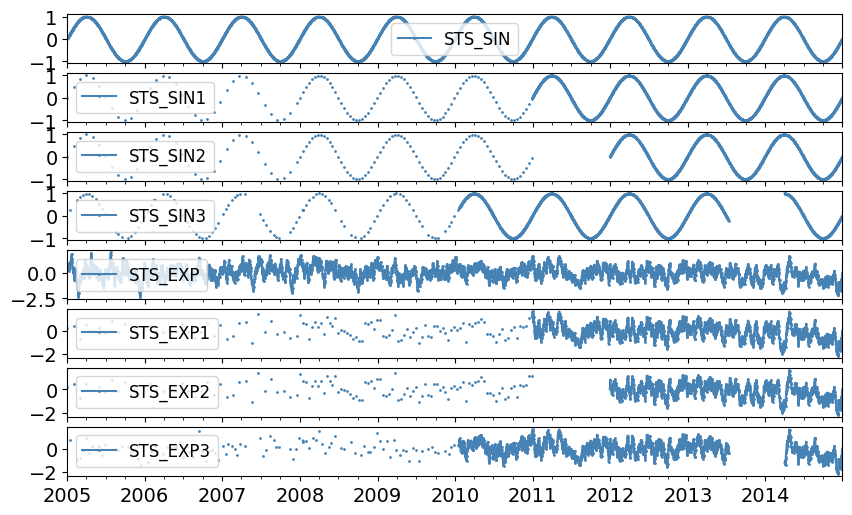

In [ ]:
n_years = 10
index = pd.to_datetime(np.arange(0, n_years * 365, 1), unit="D", origin="2005")
index.name = "Time [Years]"

# 1. Sine series: uniform sampling
np.random.seed(0)
data = np.sin(
    np.linspace(0, n_years * 2 * np.pi, len(index))
)  # +np.random.rand(index.size)
v = pd.Series(data=data, index=index, name="STS_SIN")

# 2. Sine series: three sampling densities
v1 = pd.concat(
    [
        v.iloc[: -7 * 365].asfreq("30D"),
        v.iloc[-7 * 365 : -4 * 365].asfreq("14D"),
        v.iloc[-4 * 365 :],
    ]
)
v1.name = "STS_SIN1"

# 3. Sine series: three sampling densities + a data gap
v2 = pd.concat(
    [
        v.iloc[: -7 * 365].asfreq("30D"),
        v.iloc[-7 * 365 : -4 * 365].asfreq("14D"),
        v.iloc[-3 * 365 :],
    ]
)
v2.name = "STS_SIN2"

# 4. Sine series re-indexed onto real groundwater measurement dates
v3 = v.reindex(index_test).dropna()
v3.name = "STS_SIN3"

# Convolve white noise with an exponential kernel -> AR(1)-like series
# (the kernel IS the analytical ACF of this process; used as ground truth below)
alpha = 10
np.random.seed(0)
n = np.random.rand(index.size + 365)
b = np.exp(-np.arange(366) / alpha)
n = np.convolve(n, b, mode="valid")
n = n - n.mean()

index = pd.to_datetime(np.arange(0, n.size, 1), unit="D", origin="2005")
index.name = "Time [Years]"
n = pd.Series(data=n, index=index, name="STS_EXP")

n1 = n.reindex(v1.index).dropna()
n1.name = "STS_EXP1"
n2 = n.reindex(v2.index).dropna()
n2.name = "STS_EXP2"
n3 = n.reindex(index_test).dropna()
n3.name = "STS_EXP3"

# Collect all series into a DataFrame and plot
df = pd.concat([v,v1, v2, v3,n,n1,n2,n3], axis=1)
df.plot(subplots=True, figsize=(10, 6), marker=".", markersize=2, color="steelblue");

In [ ]:
d = {s.name: s for s in [v1, v2, v3, n1, n2, n3]}
for name, s in d.items():
    print(f"{name}: n={len(s)}")

STS_SIN1: n=1576
STS_SIN2: n=1211
STS_SIN3: n=1648
STS_EXP1: n=1576
STS_EXP2: n=1211
STS_EXP3: n=1648


## ACF computation: pyzcdf vs nufftacf

In [ ]:
lags_max   = 365
lags       = np.arange(1.0, lags_max + 1)

# The truth
# ACF of a sine wave: cos(2*pi*tau / period)
period_days = 365.25
acf_v_true = pd.Series(np.cos(2 * np.pi * lags / period_days), index=lags)

# ACF of the AR(1)-like exponential process: exp(-tau / alpha)
# (the convolution kernel IS the ACF of the process)
alpha = 10.0
acf_n_true = pd.Series(np.exp(-lags / alpha), index=lags)


In [ ]:
import time

results = {}

for name, sts in d.items():
    # dropna() is essential: re-indexed series contain NaN
    # at dates where the original series had no measurement.
    sts_clean = sts.dropna()
    t = t_numeric_of(sts_clean)
    x = sts_clean.values
    n = len(x)
    print(f"Processing {name} (n={n})...", flush=True)

    t0 = time.time(); c_gauss, _ = compute_acf_gaussian_nufft(lags, t, x, bin_width=0.5);  dt_gauss = time.time()-t0
    t0 = time.time(); c_rect,  _ = compute_acf_rectangle_nufft(lags, t, x, bin_width=0.5); dt_rect  = time.time()-t0
    t0 = time.time(); zdcf_11    = run_zdcf(t, x, minpts=11, num_MC=50);                  dt_z11   = time.time()-t0
    t0 = time.time(); zdcf_25    = run_zdcf(t, x, minpts=25, num_MC=50);                  dt_z25   = time.time()-t0

    print(f"  nufftacf gaussian : {dt_gauss*1e3:6.1f} ms")
    print(f"  nufftacf rectangle: {dt_rect*1e3:6.1f} ms")
    print(f"  pyzdcf minpts=11  : {dt_z11:6.2f} s  ({len(zdcf_11)} lag bins)")
    print(f"  pyzdcf minpts=25  : {dt_z25:6.2f} s  ({len(zdcf_25)} lag bins)")

    results[name] = dict(
        c_gauss=c_gauss, c_rect=c_rect,
        zdcf_11=zdcf_11, zdcf_25=zdcf_25,
        dt_gauss=dt_gauss, dt_rect=dt_rect,
        dt_z11=dt_z11, dt_z25=dt_z25,
    )


Processing STS_SIN1 (n=1576)...
  nufftacf gaussian : 3750.2 ms
  nufftacf rectangle: 1094.5 ms
  pyzdcf minpts=11  :   7.16 s  (450 lag bins)
  pyzdcf minpts=25  :   8.07 s  (345 lag bins)
Processing STS_SIN2 (n=1211)...
  nufftacf gaussian :   71.9 ms
  nufftacf rectangle:   13.6 ms
  pyzdcf minpts=11  :   4.65 s  (442 lag bins)
  pyzdcf minpts=25  :   6.01 s  (337 lag bins)
Processing STS_SIN3 (n=1648)...
  nufftacf gaussian :   94.3 ms
  nufftacf rectangle:   19.3 ms
  pyzdcf minpts=11  :   7.46 s  (500 lag bins)
  pyzdcf minpts=25  :   8.20 s  (391 lag bins)
Processing STS_EXP1 (n=1576)...
  nufftacf gaussian :   98.3 ms
  nufftacf rectangle:   18.0 ms
  pyzdcf minpts=11  :   8.05 s  (450 lag bins)
  pyzdcf minpts=25  :   6.46 s  (345 lag bins)
Processing STS_EXP2 (n=1211)...
  nufftacf gaussian :   69.5 ms
  nufftacf rectangle:   13.6 ms
  pyzdcf minpts=11  :   5.52 s  (442 lag bins)
  pyzdcf minpts=25  :   4.58 s  (337 lag bins)
Processing STS_EXP3 (n=1648)...
  nufftacf gaussia

## Plots

In [ ]:
from matplotlib.dates import YearLocator, DateFormatter


def plot_comparison(names, results, true_acf):
    """One figure per series: nufftacf (gauss+rect) vs pyzdcf (minpts=11 and 25)."""
    n_series = len(names)
    fig, axs = plt.subplots(2, n_series, figsize=(15,8), sharey=True)

    for id, name in enumerate(names):
      # signal
      ax = axs[0,id]
      sts=d[name]
      sts.plot(ax=ax, style=".", legend=True, label=name)
      ax.xaxis.set_major_locator(YearLocator(base=3))
      ax.xaxis.set_major_formatter(DateFormatter('%Y'))

      # ACF
      res=results[name]
      ax = axs[1,id]
      #nufftacf
      ax.plot(lags, res["c_gauss"], color="tab:blue",  lw=3,
                  label=f"nufftacf gaussian ({res['dt_gauss']*1e3:.1f} ms)")
      ax.plot(lags, res["c_rect"],  color="tab:orange", lw=3, ls="--",
                  label=f"nufftacf rectangle ({res['dt_rect']*1e3:.1f} ms)")

      #truth
      if true_acf is not None:
          ax.plot(true_acf.index, true_acf.values,
                      "k--", lw=1.2, alpha=1, label="true ACF")

      #pyzdcf
      for zdcf_key, zdcf_label, dt_z,col,mkr in zip(
          ["zdcf_11",         "zdcf_25"],
          ["pyzdcf minpts=11", "pyzdcf minpts=25"],
          [res["dt_z11"],      res["dt_z25"]],
          ["red",'red'],
          ["+","x"]
      ):
          z      = res[zdcf_key]
          tau    = z["tau"].to_numpy()
          dcf    = z["dcf"].to_numpy()
          err_lo = z["-err(dcf)"].to_numpy()
          err_hi = z["+err(dcf)"].to_numpy()
          n_bins = len(z)

          ax.errorbar(
              tau, dcf, yerr=[err_lo, err_hi],
              fmt=mkr, ms=8, color=col, elinewidth=0.8, capsize=2,
              label=f"{zdcf_label} — {n_bins} bins ({dt_z:.1f} s)",
          )

          ax.set_xlabel("Lag [days]")
          ax.set_ylabel("ACF")
          ax.legend(loc="lower left")
          ax.set_xlim(1, lags_max)
          ax.set_ylim(-1.1, 1.1)
          ax.set_xticks([1, 10, 30, 60, 180, 365])
          ax.set_xticklabels([1, 10, 30, 60, 180, 365])
          ax.set_xscale("log")

    plt.tight_layout()
    plt.show()


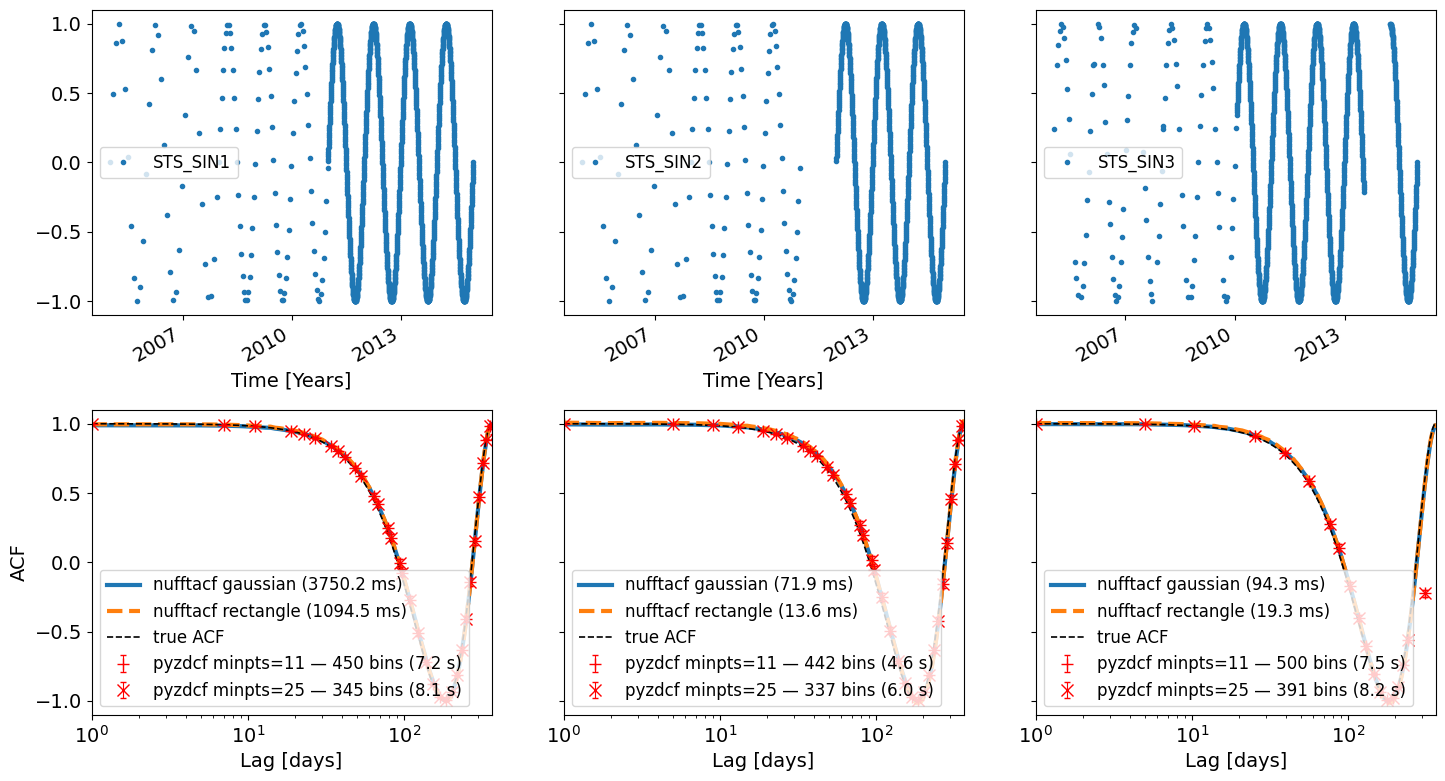

In [ ]:
# SIN series
names = ["STS_SIN1", "STS_SIN2", "STS_SIN3"]
plot_comparison(names, results, acf_v_true)


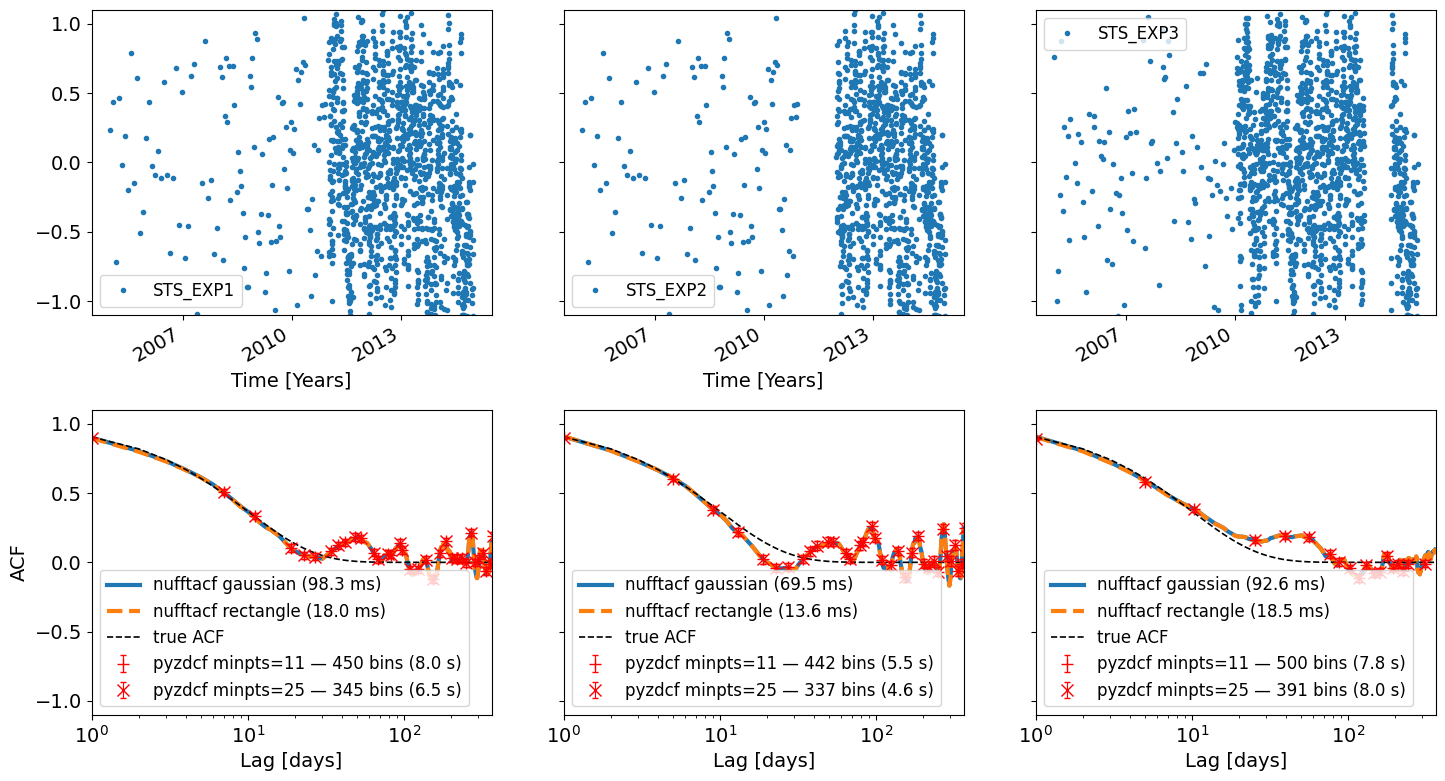

In [ ]:
# EXP series
names =  ["STS_EXP1", "STS_EXP2", "STS_EXP3"]
plot_comparison(names, results, acf_n_true)

